In [1]:
#! pip install faostat
# https://pypi.org/project/faostat/
! pip install --upgrade faostat

In [2]:
import faostat
import pandas as pd
import numpy as np
from google.colab import userdata
import requests
import matplotlib.pyplot as plt
import seaborn as sns

#Trade

Exploring the question:


> How do exports connect the world, and where are the vulnerabilities?




## Food Balances (2010-)


### World Totals/ Overview

In [3]:
mytimeout = 360
faostat.set_requests_args(username=userdata.get('faostat_user'), password=userdata.get('faostat_pwd'), timeout=mytimeout)


In [4]:
datasets = faostat.list_datasets_df()
datasets.head()

,code,label,date_update,note_update,release_current,state_current,year_current,release_next,state_next,year_next
0,QCL,Crops and livestock products,2025-12-31,,2025-12-31,final,2024,2026-12,final,2025
1,QI,Production Indices,2026-05-11,,2026-05-11,final,2024,2027-02,final,2025
2,QV,Value of Agricultural Production,2026-05-11,,2026-05-11,final,2024,2027-02,final,2025
3,FS,Suite of Food Security Indicators,2026-07-21,,2026-07-21,final,2025,2027-07,final,2026
4,FBS,Food Balances (2010-),2025-10-28,,2025-10-28,final,2023,2026-10,final,2024


In [5]:
desired_label = "Food Balances (2010-)"
desired_code = datasets[datasets['label'] == desired_label]['code'].values[0]
display(desired_code)

'FBS'

Requests should only be made for a subset of the dataset. Requesting the full dataset will fail.

In [6]:
faostat.list_pars_df(desired_code)

,parameter code,coding_systems,subdimensions {code: meaning}
0,area,"[M49, FAO, ISO2, ISO3]","{'countries': 'Countries', 'regions': 'Regions..."
1,element,[],{'elements': 'Elements'}
2,item,"[FBS, FAO]","{'items': 'Items', 'itemsagg': 'Items Aggregat..."
3,year,[],{'years': 'Years'}


In [7]:
areas = faostat.get_par_df(desired_code, 'area')
areas.head()
areas[areas['label'].str.contains("World")]

,label,code,aggregate_type
179,World + (Total),5000,+
180,World > (List),5000>,>


In [8]:
fbs = faostat.get_data_df(desired_code, pars={'area':[5000], 'area_cs':'M49'})

In [9]:
fbs.head()

,Domain Code,Domain,Area Code (M49),Area,Element Code,Element,Item Code,Item,Year Code,Year,Unit,Value
0,FBS,Food Balances (2010-),001,World,511,Total Population - Both sexes,2501,Population,2010,2010,1000 No,6948574.56
1,FBS,Food Balances (2010-),001,World,511,Total Population - Both sexes,2501,Population,2011,2011,1000 No,7036011.22
2,FBS,Food Balances (2010-),001,World,511,Total Population - Both sexes,2501,Population,2012,2012,1000 No,7161418
3,FBS,Food Balances (2010-),001,World,511,Total Population - Both sexes,2501,Population,2013,2013,1000 No,7250996.53
4,FBS,Food Balances (2010-),001,World,511,Total Population - Both sexes,2501,Population,2014,2014,1000 No,7340173.75


In [10]:
fbs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30796 entries, 0 to 30795
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Domain Code      30796 non-null  object
 1   Domain           30796 non-null  object
 2   Area Code (M49)  30796 non-null  object
 3   Area             30796 non-null  object
 4   Element Code     30796 non-null  object
 5   Element          30796 non-null  object
 6   Item Code        30796 non-null  object
 7   Item             30796 non-null  object
 8   Year Code        30796 non-null  object
 9   Year             30796 non-null  object
 10  Unit             30796 non-null  object
 11  Value            30796 non-null  object
dtypes: object(12)
memory usage: 2.8+ MB


In [11]:
fbs.describe()

,Domain Code,Domain,Area Code (M49),Area,Element Code,Element,Item Code,Item,Year Code,Year,Unit,Value
count,30796,30796,30796,30796,30796,30796,30796,30796,30796,30796,30796,30796
unique,1,1,1,1,21,21,123,120,14,14,7,17155
top,FBS,Food Balances (2010-),001,World,664,Food supply (kcal/capita/day),2807,Milk - Excluding Butter,2014,2014,1000 t,0
freq,30796,30796,30796,30796,1676,1676,280,532,2212,2212,19070,2051


In [12]:
fbs.Item.unique()

array(['Population', 'Grand Total', 'Vegetal Products', 'Animal Products',
       'Cereals - Excluding Beer', 'Wheat and products',
       'Rice and products', 'Barley and products', 'Maize and products',
       'Rye and products', 'Oats', 'Millet and products',
       'Sorghum and products', 'Cereals, other', 'Starchy Roots',
       'Cassava and products', 'Potatoes and products', 'Sweet potatoes',
       'Yams', 'Roots, Other', 'Sugar Crops', 'Sugar cane', 'Sugar beet',
       'Sugar & Sweeteners', 'Sugar non-centrifugal',
       'Sugar (Raw Equivalent)', 'Sweeteners, Other', 'Honey', 'Pulses',
       'Beans', 'Peas', 'Pulses, Other and products', 'Treenuts',
       'Nuts and products', 'Oilcrops', 'Soyabeans', 'Groundnuts',
       'Sunflower seed', 'Rape and Mustardseed', 'Cottonseed',
       'Coconuts - Incl Copra', 'Sesame seed', 'Palm kernels',
       'Olives (including preserved)', 'Oilcrops, Other',
       'Vegetable Oils', 'Soyabean Oil', 'Groundnut Oil',
       'Sunflowerseed

In [13]:
fbs.Element.unique()

array(['Total Population - Both sexes', 'Food supply (kcal/capita/day)',
       'Food supply (kcal)', 'Protein supply quantity (g/capita/day)',
       'Protein supply quantity (t)',
       'Fat supply quantity (g/capita/day)', 'Fat supply quantity (t)',
       'Production', 'Import quantity', 'Stock Variation',
       'Export quantity', 'Domestic supply quantity', 'Feed', 'Seed',
       'Losses', 'Processing', 'Other uses (non-food)',
       'Tourist consumption', 'Residuals', 'Food',
       'Food supply quantity (kg/capita/yr)'], dtype=object)

###Let's start by looking at fluctuations in World Population.

In [14]:
world_pop = fbs[fbs['Item']=="Population"][["Year","Unit","Value"]]
display(world_pop)


,Year,Unit,Value
0,2010,1000 No,6948574.56
1,2011,1000 No,7036011.22
2,2012,1000 No,7161418
3,2013,1000 No,7250996.53
4,2014,1000 No,7340173.75
5,2015,1000 No,7428662.2
6,2016,1000 No,7516541.25
7,2017,1000 No,7603845.92
8,2018,1000 No,7687976.19
9,2019,1000 No,7784526.29


In [15]:
world_pop.Value = world_pop.Value.astype(float)

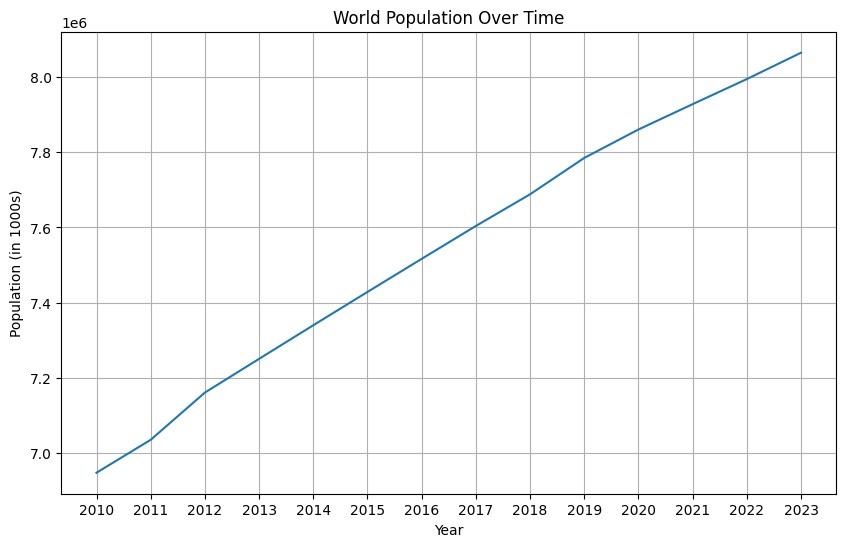

In [16]:
plt.figure(figsize=(10, 6))
sns.lineplot(data=world_pop, x='Year', y='Value')
plt.title('World Population Over Time')
plt.xlabel('Year')
plt.ylabel('Population (in 1000s)')
plt.grid(True)
plt.show()

### World Calories per Capital

In [17]:
#world infant food
world_infant_food = fbs[fbs['Item']=="Infant food"][["Year","Unit","Value","Element"]]
world_infant_food.Value = world_infant_food.Value.astype(float)
display(world_infant_food)

,Year,Unit,Value,Element
30374,2010,1000 t,0.00,Production
30375,2010,1000 t,777.00,Import quantity
30376,2010,1000 t,-50.00,Stock Variation
30377,2010,1000 t,754.00,Export quantity
30378,2010,1000 t,73.00,Domestic supply quantity
...,...,...,...,...
30576,2023,million Kcal,2790973.24,Food supply (kcal)
30577,2023,g/cap/d,0.03,Protein supply quantity (g/capita/day)
30578,2023,t,83638.29,Protein supply quantity (t)
30579,2023,g/cap/d,0.04,Fat supply quantity (g/capita/day)


In [18]:
world_infant_food.Element.unique()

array(['Production', 'Import quantity', 'Stock Variation',
       'Export quantity', 'Domestic supply quantity',
       'Tourist consumption', 'Residuals', 'Food',
       'Food supply quantity (kg/capita/yr)',
       'Food supply (kcal/capita/day)', 'Food supply (kcal)',
       'Protein supply quantity (g/capita/day)',
       'Protein supply quantity (t)',
       'Fat supply quantity (g/capita/day)', 'Fat supply quantity (t)',
       'Other uses (non-food)'], dtype=object)

In [19]:
world_infant_food.Unit.unique()

array(['1000 t', 'kg/cap', 'kcal/cap/d', 'million Kcal', 'g/cap/d', 't'],
      dtype=object)

In [20]:
#using kcal/capita/day to see how well we're feeding the global population over time
kcal_infant_food = world_infant_food[world_infant_food['Unit']=="kcal/cap/d"]
display(kcal_infant_food)

,Year,Unit,Value,Element
30383,2010,kcal/cap/d,0.75,Food supply (kcal/capita/day)
30398,2011,kcal/cap/d,0.81,Food supply (kcal/capita/day)
30413,2012,kcal/cap/d,0.85,Food supply (kcal/capita/day)
30428,2013,kcal/cap/d,0.86,Food supply (kcal/capita/day)
30444,2014,kcal/cap/d,0.91,Food supply (kcal/capita/day)
30459,2015,kcal/cap/d,0.95,Food supply (kcal/capita/day)
30474,2016,kcal/cap/d,0.96,Food supply (kcal/capita/day)
30489,2017,kcal/cap/d,1.03,Food supply (kcal/capita/day)
30504,2018,kcal/cap/d,1.03,Food supply (kcal/capita/day)
30519,2019,kcal/cap/d,1.05,Food supply (kcal/capita/day)


In [21]:
t1000_infant_food = world_infant_food[(world_infant_food['Unit']=="1000 t")&(world_infant_food['Element']=='Food')]
display(t1000_infant_food)
t1000_infant_food.Element.unique()

,Year,Unit,Value,Element
30381,2010,1000 t,620.0,Food
30396,2011,1000 t,674.0,Food
30411,2012,1000 t,722.0,Food
30426,2013,1000 t,745.0,Food
30442,2014,1000 t,791.0,Food
30457,2015,1000 t,839.0,Food
30472,2016,1000 t,859.0,Food
30487,2017,1000 t,933.0,Food
30502,2018,1000 t,939.0,Food
30517,2019,1000 t,976.0,Food


array(['Food'], dtype=object)

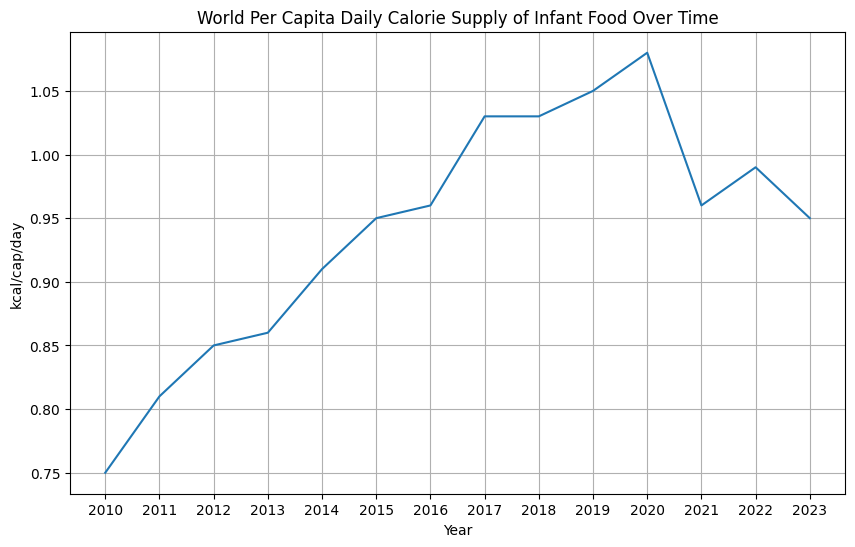

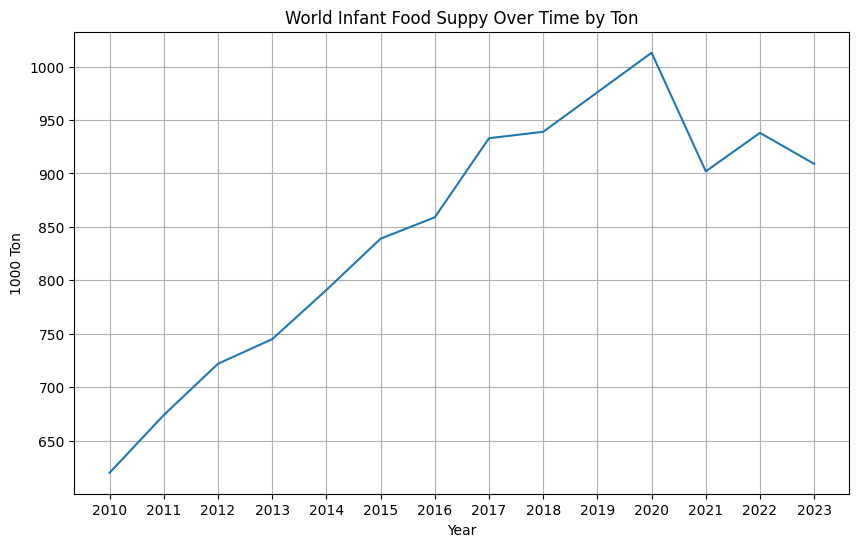

In [22]:
plt.figure(figsize=(10, 6))
sns.lineplot(data=kcal_infant_food, x='Year', y='Value')
plt.title('World Per Capita Daily Calorie Supply of Infant Food Over Time')
plt.xlabel('Year')
plt.ylabel('kcal/cap/day')
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 6))
sns.lineplot(data=t1000_infant_food, x='Year', y='Value')
plt.title('World Infant Food Suppy Over Time by Ton')
plt.xlabel('Year')
plt.ylabel('1000 Ton')
plt.grid(True)
plt.show()

Supply of Infant Food decreased starting in 2020 inspite of continued population increase. It does not apear that the infant food has become less caloricaly dense.

In [23]:
fbs[fbs["Item"] == "Grand Total"].head()

,Domain Code,Domain,Area Code (M49),Area,Element Code,Element,Item Code,Item,Year Code,Year,Unit,Value
14,FBS,Food Balances (2010-),001,World,664,Food supply (kcal/capita/day),2901,Grand Total,2010,2010,kcal/cap/d,2825.19
15,FBS,Food Balances (2010-),001,World,661,Food supply (kcal),2901,Grand Total,2010,2010,million Kcal,7165321578.45
16,FBS,Food Balances (2010-),001,World,674,Protein supply quantity (g/capita/day),2901,Grand Total,2010,2010,g/cap/d,84.81
17,FBS,Food Balances (2010-),001,World,671,Protein supply quantity (t),2901,Grand Total,2010,2010,t,215092833.93
18,FBS,Food Balances (2010-),001,World,684,Fat supply quantity (g/capita/day),2901,Grand Total,2010,2010,g/cap/d,77.92


In [24]:
world_food_overview = fbs[fbs['Item'].isin(['Vegetal Products', 'Animal Products',
       'Cereals - Excluding Beer', 'Grand Total'])][["Year","Item", "Unit","Value","Element"]]
world_food_overview.Value = world_food_overview.Value.astype(float)
display(world_food_overview)

,Year,Item,Unit,Value,Element
14,2010,Grand Total,kcal/cap/d,2.825190e+03,Food supply (kcal/capita/day)
15,2010,Grand Total,million Kcal,7.165322e+09,Food supply (kcal)
16,2010,Grand Total,g/cap/d,8.481000e+01,Protein supply quantity (g/capita/day)
17,2010,Grand Total,t,2.150928e+08,Protein supply quantity (t)
18,2010,Grand Total,g/cap/d,7.792000e+01,Fat supply quantity (g/capita/day)
...,...,...,...,...,...
541,2023,Cereals - Excluding Beer,million Kcal,3.767740e+09,Food supply (kcal)
542,2023,Cereals - Excluding Beer,g/cap/d,3.338000e+01,Protein supply quantity (g/capita/day)
543,2023,Cereals - Excluding Beer,t,9.826021e+07,Protein supply quantity (t)
544,2023,Cereals - Excluding Beer,g/cap/d,6.820000e+00,Fat supply quantity (g/capita/day)


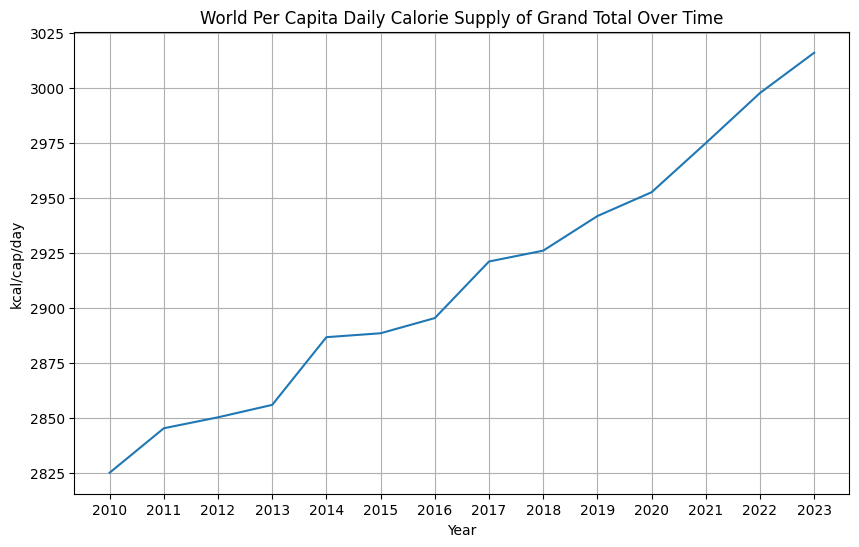

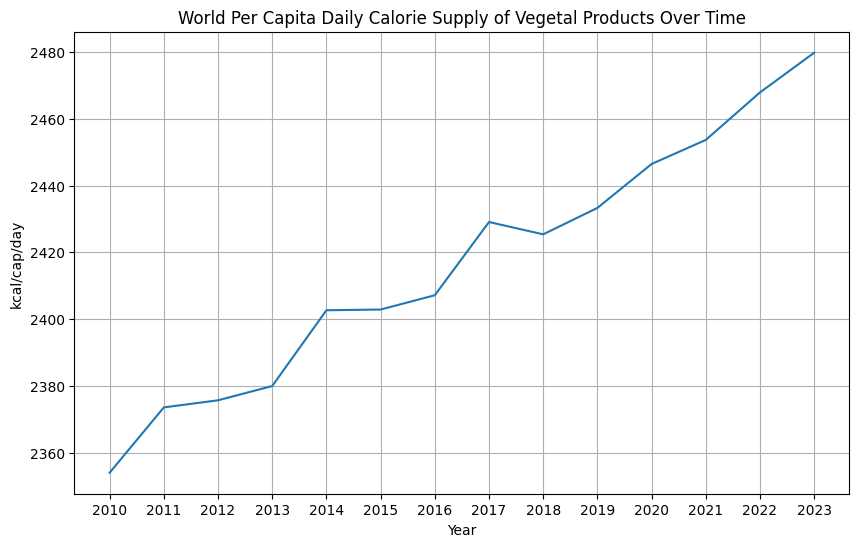

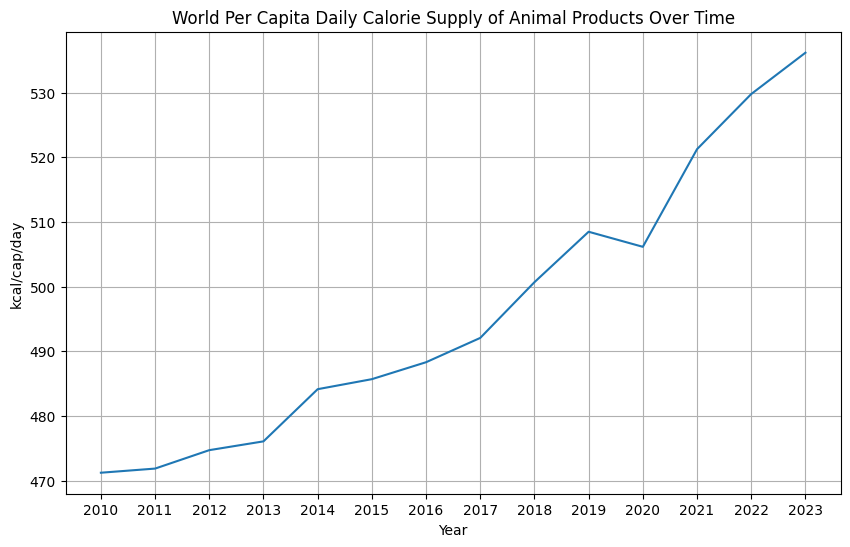

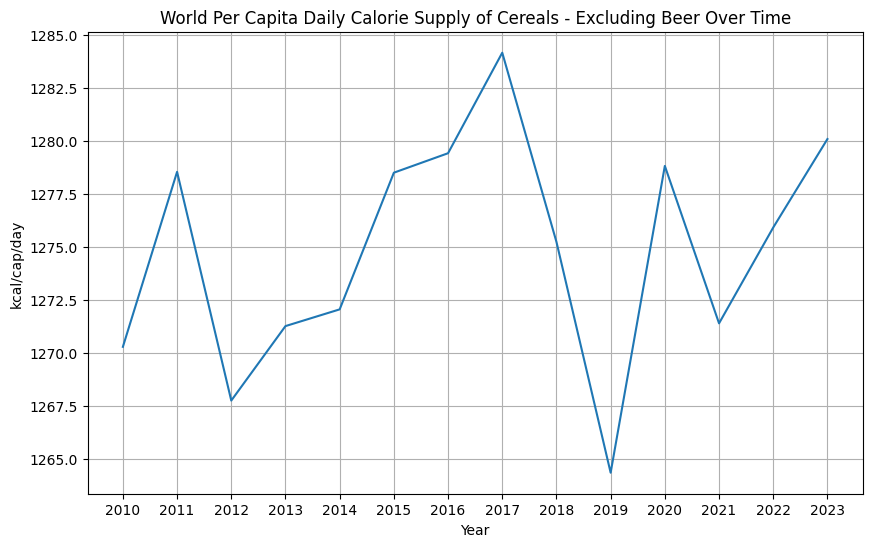

In [25]:
for item in world_food_overview.Item.unique():
  df = world_food_overview[world_food_overview['Item'] == item]
  supply_df = df[df['Unit']=='kcal/cap/d']
  plt.figure(figsize=(10, 6))
  sns.lineplot(data=supply_df, x='Year', y='Value')
  plt.title(f'World Per Capita Daily Calorie Supply of {item} Over Time')
  plt.xlabel('Year')
  plt.ylabel('kcal/cap/day')
  plt.grid(True)
  plt.show()

Globally we can see that there are more than enough calories being produced to feed every person the average adult's recommended daily calorie intake

https://health.clevelandclinic.org/how-many-calories-a-day-should-i-eat

In [26]:
display(areas)

,label,code,aggregate_type
0,Afghanistan,2,0
1,Albania,3,0
2,Algeria,4,0
3,Angola,7,0
4,Antigua and Barbuda,8,0
...,...,...,...
242,Small Island Developing States (SIDS) > (List),5803>,>
243,Low Income Food Deficit Countries (LIFDCs) + (...,5815,+
244,Low Income Food Deficit Countries (LIFDCs) > (...,5815>,>
245,Net Food Importing Developing Countries (NFIDC...,5817,+


In [27]:
items = faostat.get_par_df(desired_code, 'item')
items['label'].unique()

array(['Population', 'Wheat and products', 'Rice and products',
       'Barley and products', 'Maize and products', 'Rye and products',
       'Oats', 'Millet and products', 'Sorghum and products',
       'Cereals, other', 'Cassava and products', 'Potatoes and products',
       'Sweet potatoes', 'Yams', 'Roots, Other', 'Sugar cane',
       'Sugar beet', 'Sugar non-centrifugal', 'Sugar (Raw Equivalent)',
       'Sweeteners, Other', 'Honey', 'Beans', 'Peas',
       'Pulses, Other and products', 'Nuts and products', 'Soyabeans',
       'Groundnuts', 'Sunflower seed', 'Rape and Mustardseed',
       'Cottonseed', 'Coconuts - Incl Copra', 'Sesame seed',
       'Palm kernels', 'Olives (including preserved)', 'Oilcrops, Other',
       'Soyabean Oil', 'Groundnut Oil', 'Sunflowerseed Oil',
       'Rape and Mustard Oil', 'Cottonseed Oil', 'Palmkernel Oil',
       'Palm Oil', 'Coconut Oil', 'Sesameseed Oil', 'Olive Oil',
       'Ricebran Oil', 'Maize Germ Oil', 'Oilcrops Oil, Other',
       'Tomat

In [28]:
item_codes = items[(items['label'] == 'Population')|(items['label'] == 'Infant food')|(items['label'] == 'Grand Total + (Total)')]['code'].values

In [29]:
areas.code.dtype

dtype('O')

In [30]:
#-----------------------------------Africa--------------------------------------------------
#east africa
east_africa = faostat.get_data_df(desired_code,
    pars={
        "area": ["5101>"],
        "item": item_codes
    },
    coding={
        "area": "M49"
    },
    limit=5000
)
#west africa
west_africa = faostat.get_data_df(desired_code,
    pars={
        "area": ["5105>"],
        "item": item_codes
    },
    coding={
        "area": "M49"
    },
    limit=5000
)
#north africa
north_africa = faostat.get_data_df(desired_code,
    pars={
        "area": ["5103>"],
        "item": item_codes
    },
    coding={
        "area": "M49"
    },
    limit=5000
)
#south africa
south_africa = faostat.get_data_df(desired_code,
    pars={
        "area": ["5104>"],
        "item": item_codes
    },
    coding={
        "area": "M49"
    },
    limit=5000
)
#middle africa
mid_africa = faostat.get_data_df(desired_code,
    pars={
        "area": ["5102>"],
        "item": item_codes
    },
    coding={
        "area": "M49"
    },
    limit=5000
)
#-----------------------------------Americas--------------------------------------------------
#north america
north_america = faostat.get_data_df(desired_code,
    pars={
        "area": ["5203>"],
        "item": item_codes
    },
    coding={
        "area": "M49"
    },
    limit=5000
)
#central america
central_america = faostat.get_data_df(desired_code,
    pars={
        "area": ["5204>"],
        "item": item_codes
    },
    coding={
        "area": "M49"
    },
    limit=5000
)
#caribean
caribean = faostat.get_data_df(desired_code,
    pars={
        "area": ["5206>"],
        "item": item_codes
    },
    coding={
        "area": "M49"
    },
    limit=5000
)
#south america
south_america = faostat.get_data_df(desired_code,
    pars={
        "area": ["5207>"],
        "item": item_codes
    },
    coding={
        "area": "M49"
    },
    limit=5000
)
#-----------------------------------Asia--------------------------------------------------
#central asia
central_asia = faostat.get_data_df(desired_code,
    pars={
        "area": ["5301>"],
        "item": item_codes
    },
    coding={
        "area": "M49"
    },
    limit=5000
)
#eastern asia
eastern_asia = faostat.get_data_df(desired_code,
    pars={
        "area": ["5302>"],
        "item": item_codes
    },
    coding={
        "area": "M49"
    },
    limit=5000
)
#southern asia
southern_asia = faostat.get_data_df(desired_code,
    pars={
        "area": ["5303>"],
        "item": item_codes
    },
    coding={
        "area": "M49"
    },
    limit=5000
)
#south-eastern asia
se_asia = faostat.get_data_df(desired_code,
    pars={
        "area": ["5304>"],
        "item": item_codes
    },
    coding={
        "area": "M49"
    },
    limit=5000
)
#western asia
western_asia = faostat.get_data_df(desired_code,
    pars={
        "area": ["5305>"],
        "item": item_codes
    },
    coding={
        "area": "M49"
    },
    limit=5000
)
#-----------------------------------Europe--------------------------------------------------
#eastern_europe
eastern_europe = faostat.get_data_df(desired_code,
    pars={
        "area": ["5401>"],
        "item": item_codes
    },
    coding={
        "area": "M49"
    },
    limit=5000
)
#northern europe
northern_europe = faostat.get_data_df(desired_code,
    pars={
        "area": ["5402>"],
        "item": item_codes
    },
    coding={
        "area": "M49"
    },
    limit=5000
)
#southern europe
southern_europe = faostat.get_data_df(desired_code,
    pars={
        "area": ["5403>"],
        "item": item_codes
    },
    coding={
        "area": "M49"
    },
    limit=5000
)
#western europe
western_europe = faostat.get_data_df(desired_code,
    pars={
        "area": ["5404>"],
        "item": item_codes
    },
    coding={
        "area": "M49"
    },
    limit=5000
)
#-----------------------------------Oceania--------------------------------------------------
#australia nz
australia_nz = faostat.get_data_df(desired_code,
    pars={
        "area": ["5501>"],
        "item": item_codes
    },
    coding={
        "area": "M49"
    },
    limit=5000
)
#melanesia
melanesia = faostat.get_data_df(desired_code,
    pars={
        "area": ["5502>"],
        "item": item_codes
    },
    coding={
        "area": "M49"
    },
    limit=5000
)
#micronesia
micronesia = faostat.get_data_df(desired_code,
    pars={
        "area": ["5503>"],
        "item": item_codes
    },
    coding={
        "area": "M49"
    },
    limit=5000
)
#polynesia
polynesia = faostat.get_data_df(desired_code,
    pars={
        "area": ["5504>"],
        "item": item_codes
    },
    coding={
        "area": "M49"
    },
    limit=5000
)


In [31]:
africa = {"East Africa":east_africa,"West Africa":west_africa,"Middle Africa":mid_africa, "North Africa":north_africa, "South Africa":south_africa}
americas = {"North America":north_america, "Central America":central_america, "Caribean":caribean, "South America": south_america}
asia = {"Central Asia":central_asia, "Eastern Asia":eastern_asia, "Southern Asia":southern_asia, "South-Eastern Asia":se_asia, "Western Asia":western_asia}
europe = {"Eastern Europe":eastern_europe, "Northern Europe":northern_europe, "Southern Europe":southern_europe, "Western Europe":western_europe}
oceania = {"Australia/New Zealand":australia_nz, "Melanesia":melanesia, "Micronesia":micronesia, "Polynesia":polynesia}
regions = {"Africa":africa, "America":americas, "Asia":asia, "Europe":europe, "Oceania":oceania}

In [32]:
for dic in regions.values():
  for label, area in dic.items():
    print(label)
    print(area.info())
    display(area.describe())

East Africa
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3902 entries, 0 to 3901
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Domain Code      3902 non-null   object
 1   Domain           3902 non-null   object
 2   Area Code (M49)  3902 non-null   object
 3   Area             3902 non-null   object
 4   Element Code     3902 non-null   object
 5   Element          3902 non-null   object
 6   Item Code        3902 non-null   object
 7   Item             3902 non-null   object
 8   Year Code        3902 non-null   object
 9   Year             3902 non-null   object
 10  Unit             3902 non-null   object
 11  Value            3902 non-null   object
dtypes: object(12)
memory usage: 365.9+ KB
None


,Domain Code,Domain,Area Code (M49),Area,Element Code,Element,Item Code,Item,Year Code,Year,Unit,Value
count,3902,3902,3902,3902,3902,3902,3902,3902,3902,3902,3902,3902
unique,1,1,14,14,15,15,3,3,14,14,7,2051
top,FBS,Food Balances (2010-),404,Kenya,664,Food supply (kcal/capita/day),2680,Infant food,2010,2010,1000 t,0
freq,3902,3902,294,294,392,392,2530,2530,281,281,1158,1058


West Africa
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3574 entries, 0 to 3573
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Domain Code      3574 non-null   object
 1   Domain           3574 non-null   object
 2   Area Code (M49)  3574 non-null   object
 3   Area             3574 non-null   object
 4   Element Code     3574 non-null   object
 5   Element          3574 non-null   object
 6   Item Code        3574 non-null   object
 7   Item             3574 non-null   object
 8   Year Code        3574 non-null   object
 9   Year             3574 non-null   object
 10  Unit             3574 non-null   object
 11  Value            3574 non-null   object
dtypes: object(12)
memory usage: 335.2+ KB
None


,Domain Code,Domain,Area Code (M49),Area,Element Code,Element,Item Code,Item,Year Code,Year,Unit,Value
count,3574,3574,3574,3574,3574,3574,3574,3574,3574,3574,3574,3574
unique,1,1,13,13,15,15,3,3,14,14,7,1917
top,FBS,Food Balances (2010-),132,Cabo Verde,664,Food supply (kcal/capita/day),2680,Infant food,2010,2010,1000 t,0
freq,3574,3574,283,283,364,364,2300,2300,257,257,1026,664


Middle Africa
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1657 entries, 0 to 1656
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Domain Code      1657 non-null   object
 1   Domain           1657 non-null   object
 2   Area Code (M49)  1657 non-null   object
 3   Area             1657 non-null   object
 4   Element Code     1657 non-null   object
 5   Element          1657 non-null   object
 6   Item Code        1657 non-null   object
 7   Item             1657 non-null   object
 8   Year Code        1657 non-null   object
 9   Year             1657 non-null   object
 10  Unit             1657 non-null   object
 11  Value            1657 non-null   object
dtypes: object(12)
memory usage: 155.5+ KB
None


...

,Domain Code,Domain,Area Code (M49),Area,Element Code,Element,Item Code,Item,Year Code,Year,Unit,Value
count,1405,1405,1405,1405,1405,1405,1405,1405,1405,1405,1405,1405
unique,1,1,5,5,15,15,3,3,14,14,7,711
top,FBS,Food Balances (2010-),242,Fiji,664,Food supply (kcal/capita/day),2680,Infant food,2010,2010,1000 t,0
freq,1405,1405,290,290,140,140,915,915,101,101,425,513


Micronesia
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 533 entries, 0 to 532
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Domain Code      533 non-null    object
 1   Domain           533 non-null    object
 2   Area Code (M49)  533 non-null    object
 3   Area             533 non-null    object
 4   Element Code     533 non-null    object
 5   Element          533 non-null    object
 6   Item Code        533 non-null    object
 7   Item             533 non-null    object
 8   Year Code        533 non-null    object
 9   Year             533 non-null    object
 10  Unit             533 non-null    object
 11  Value            533 non-null    object
dtypes: object(12)
memory usage: 50.1+ KB
None


,Domain Code,Domain,Area Code (M49),Area,Element Code,Element,Item Code,Item,Year Code,Year,Unit,Value
count,533,533,533,533,533,533,533,533,533,533,533,533
unique,1,1,4,4,15,15,3,3,14,14,7,284
top,FBS,Food Balances (2010-),296,Kiribati,664,Food supply (kcal/capita/day),2680,Infant food,2023,2023,1000 t,0
freq,533,533,275,275,56,56,330,330,75,75,141,175


Polynesia
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 730 entries, 0 to 729
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Domain Code      730 non-null    object
 1   Domain           730 non-null    object
 2   Area Code (M49)  730 non-null    object
 3   Area             730 non-null    object
 4   Element Code     730 non-null    object
 5   Element          730 non-null    object
 6   Item Code        730 non-null    object
 7   Item             730 non-null    object
 8   Year Code        730 non-null    object
 9   Year             730 non-null    object
 10  Unit             730 non-null    object
 11  Value            730 non-null    object
dtypes: object(12)
memory usage: 68.6+ KB
None


,Domain Code,Domain,Area Code (M49),Area,Element Code,Element,Item Code,Item,Year Code,Year,Unit,Value
count,730,730,730,730,730,730,730,730,730,730,730,730
unique,1,1,4,4,15,15,3,3,14,14,7,432
top,FBS,Food Balances (2010-),258,French Polynesia,664,Food supply (kcal/capita/day),2680,Infant food,2020,2020,1000 t,0
freq,730,730,288,288,74,74,464,464,78,78,212,218


In [33]:
east_africa.head()

,Domain Code,Domain,Area Code (M49),Area,Element Code,Element,Item Code,Item,Year Code,Year,Unit,Value
0,FBS,Food Balances (2010-),174,Comoros,511,Total Population - Both sexes,2501,Population,2010,2010,1000 No,654.84
1,FBS,Food Balances (2010-),174,Comoros,511,Total Population - Both sexes,2501,Population,2011,2011,1000 No,668.06
2,FBS,Food Balances (2010-),174,Comoros,511,Total Population - Both sexes,2501,Population,2012,2012,1000 No,681.63
3,FBS,Food Balances (2010-),174,Comoros,511,Total Population - Both sexes,2501,Population,2013,2013,1000 No,696.19
4,FBS,Food Balances (2010-),174,Comoros,511,Total Population - Both sexes,2501,Population,2014,2014,1000 No,711.5


In [34]:
east_africa.Item.unique()

array(['Population', 'Grand Total', 'Infant food'], dtype=object)

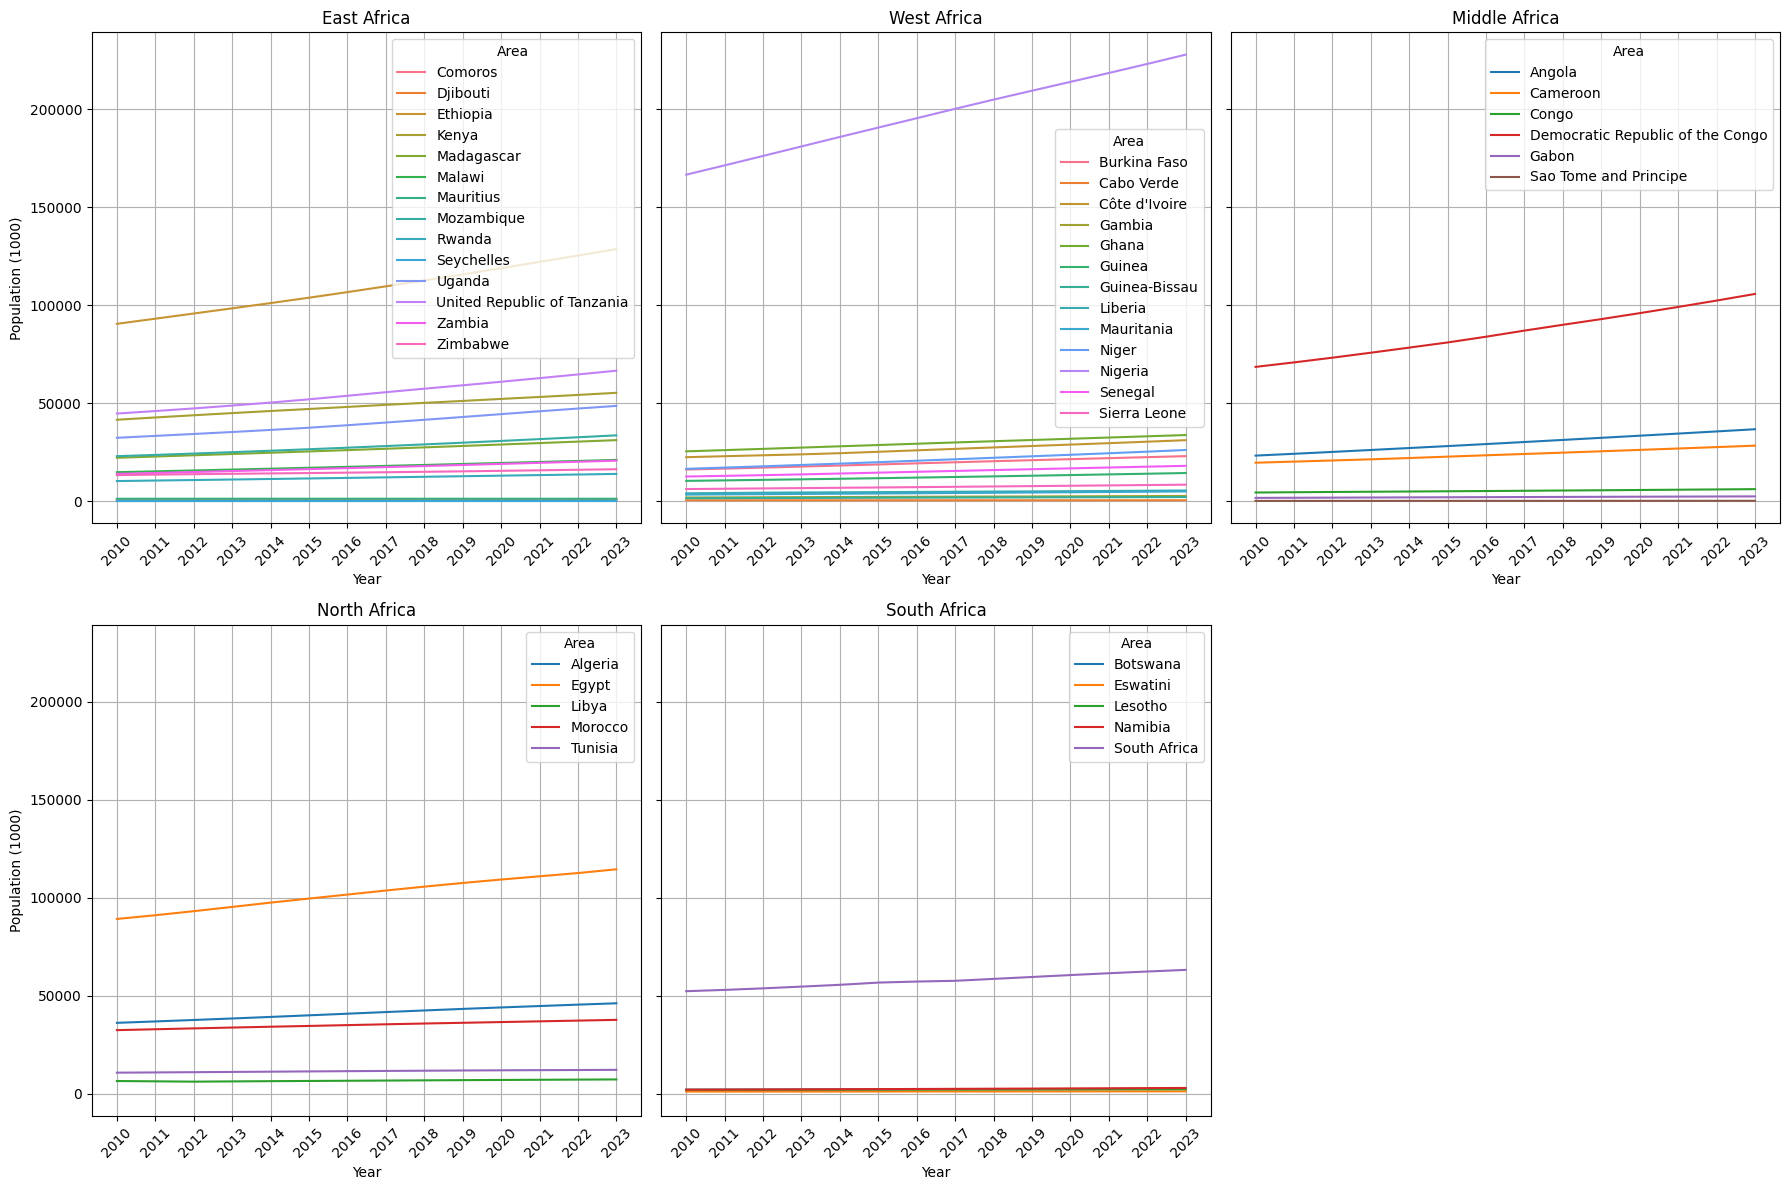

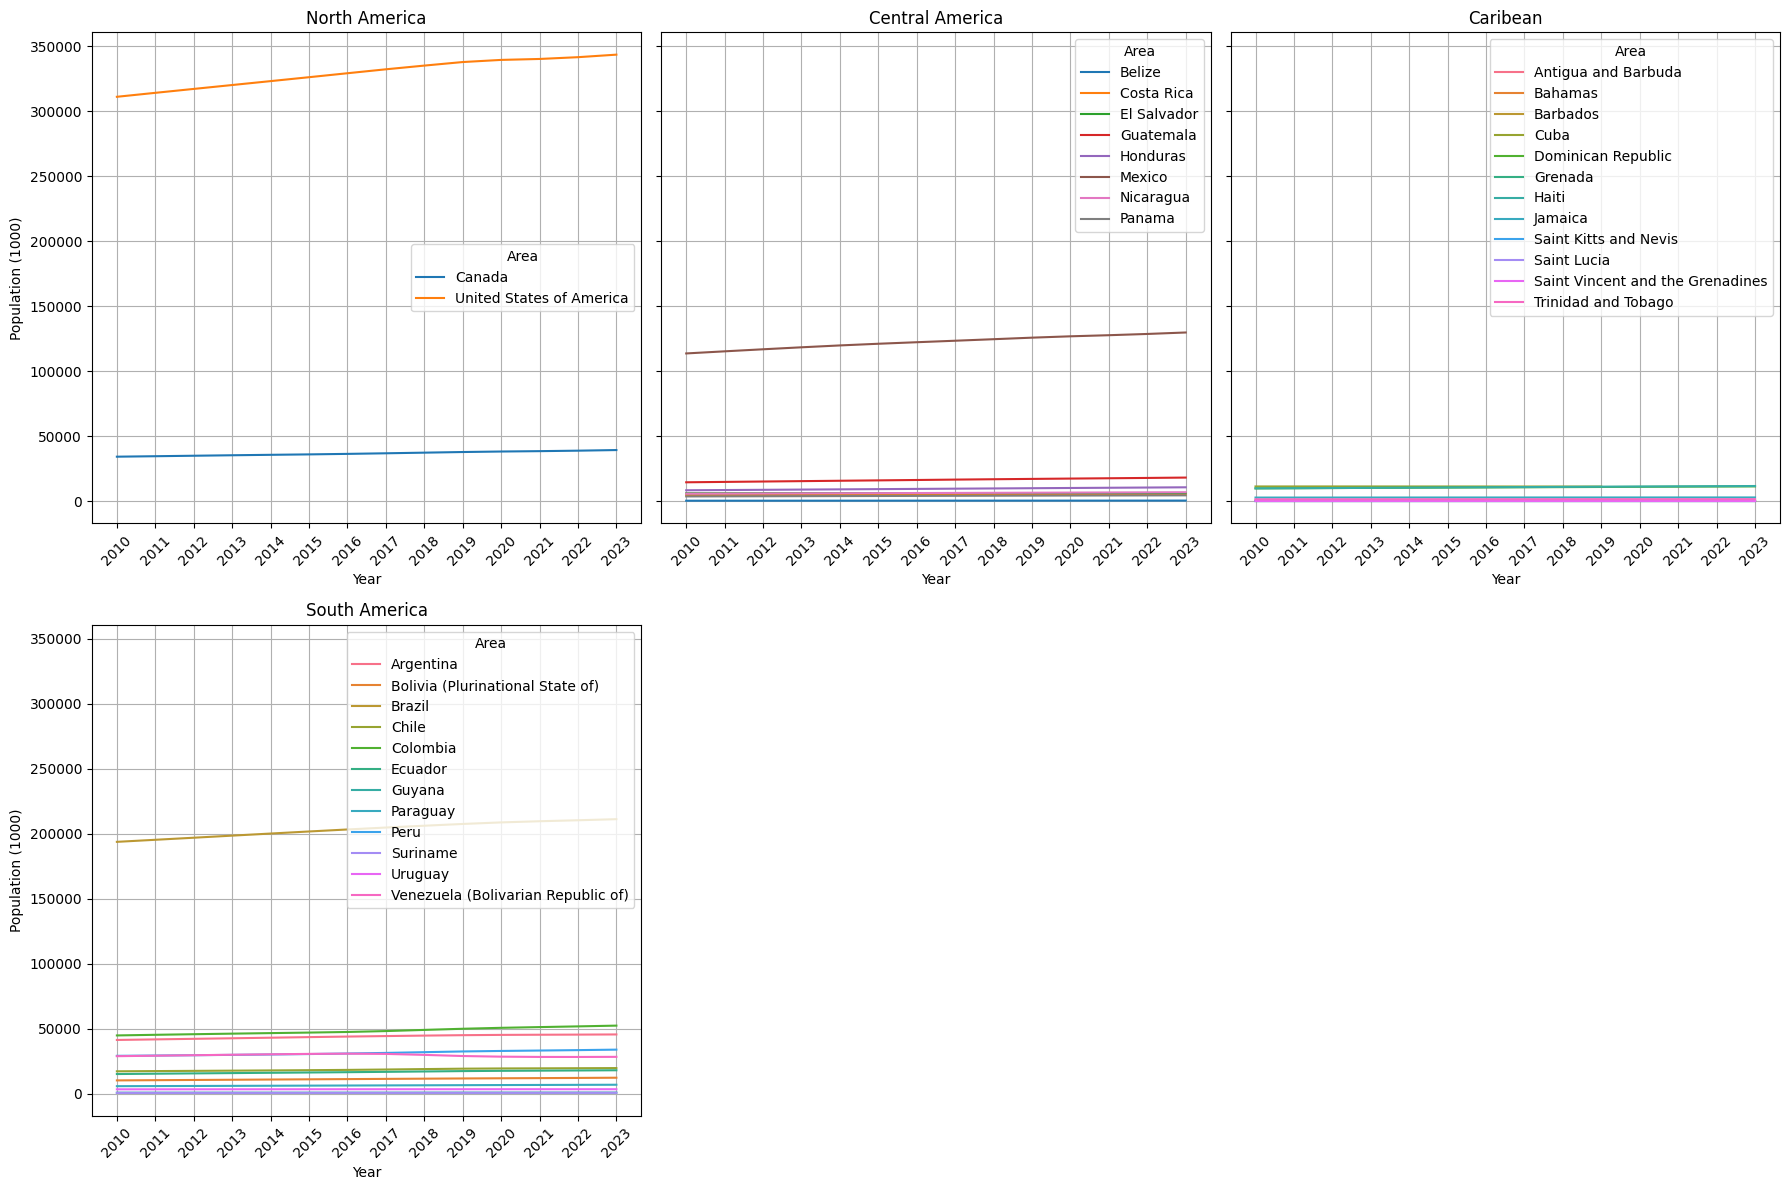

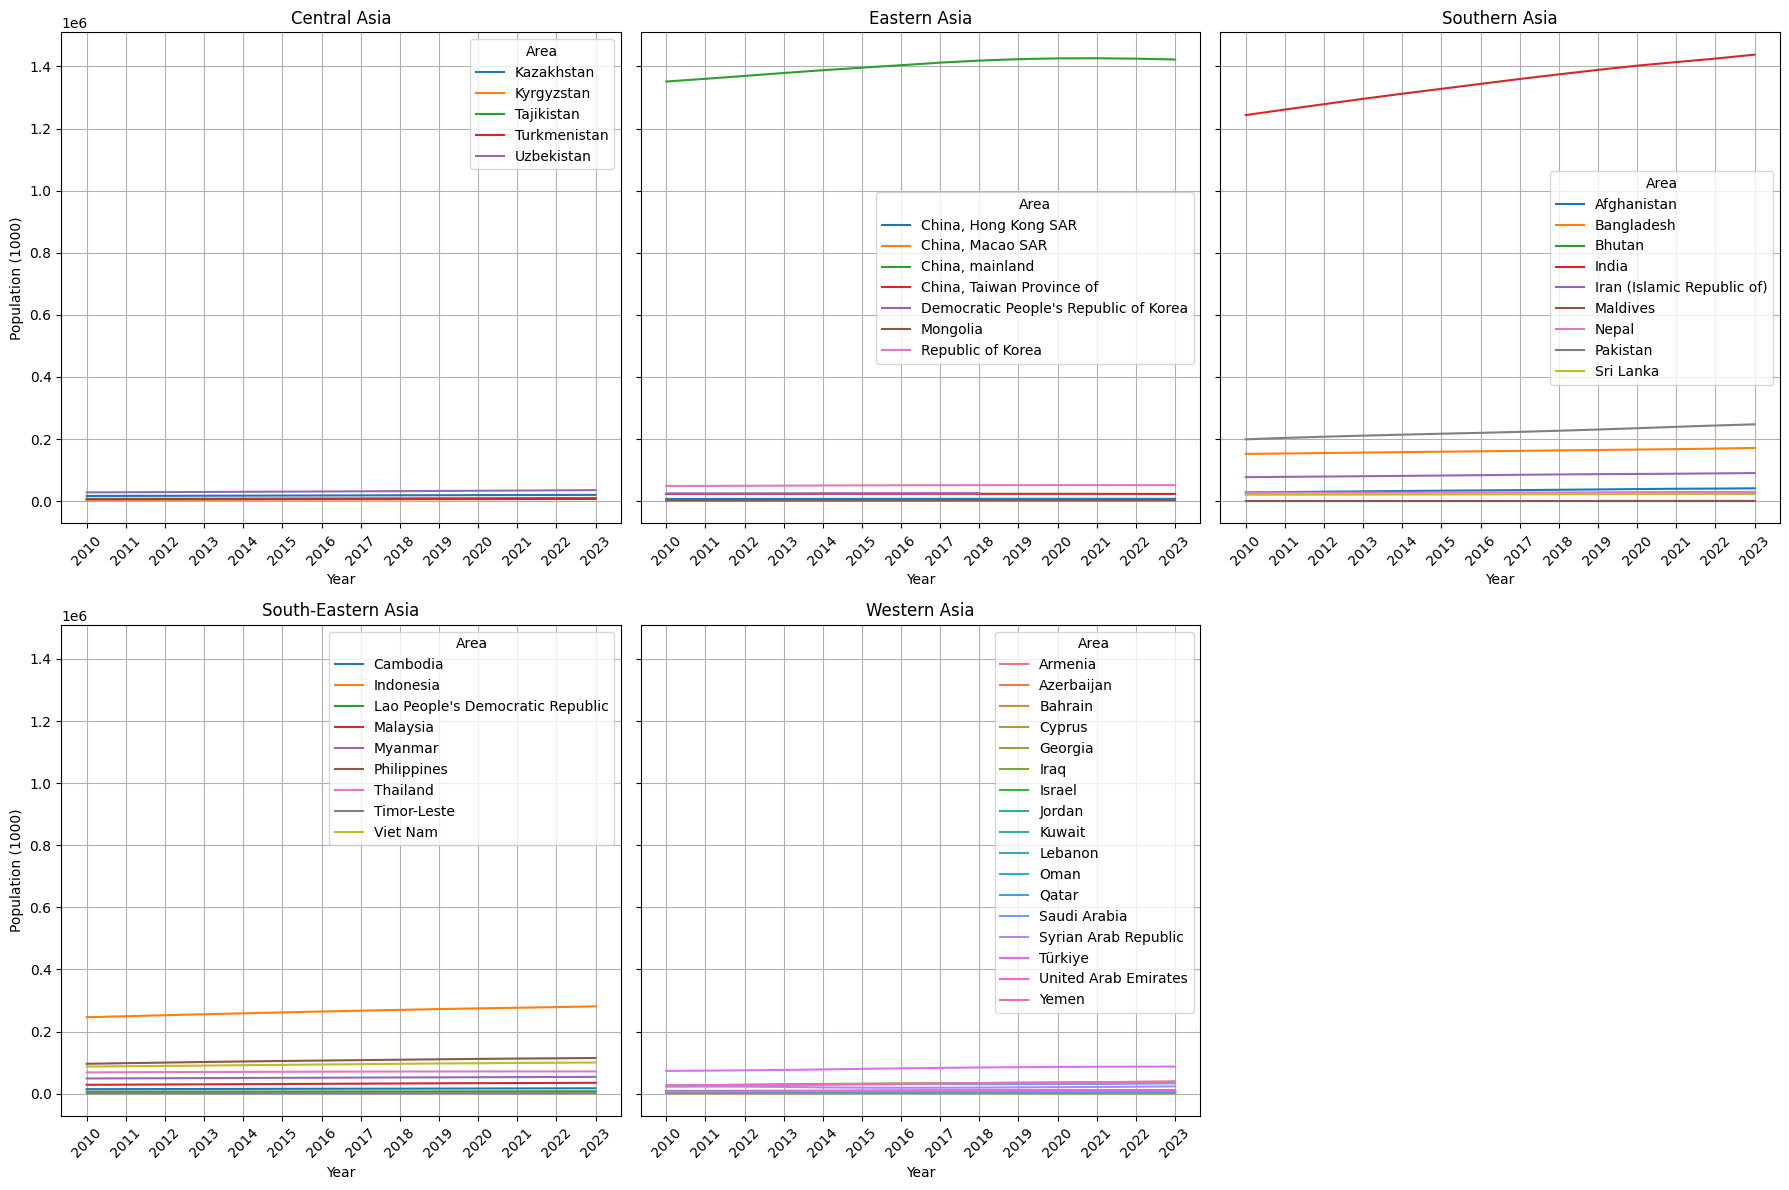

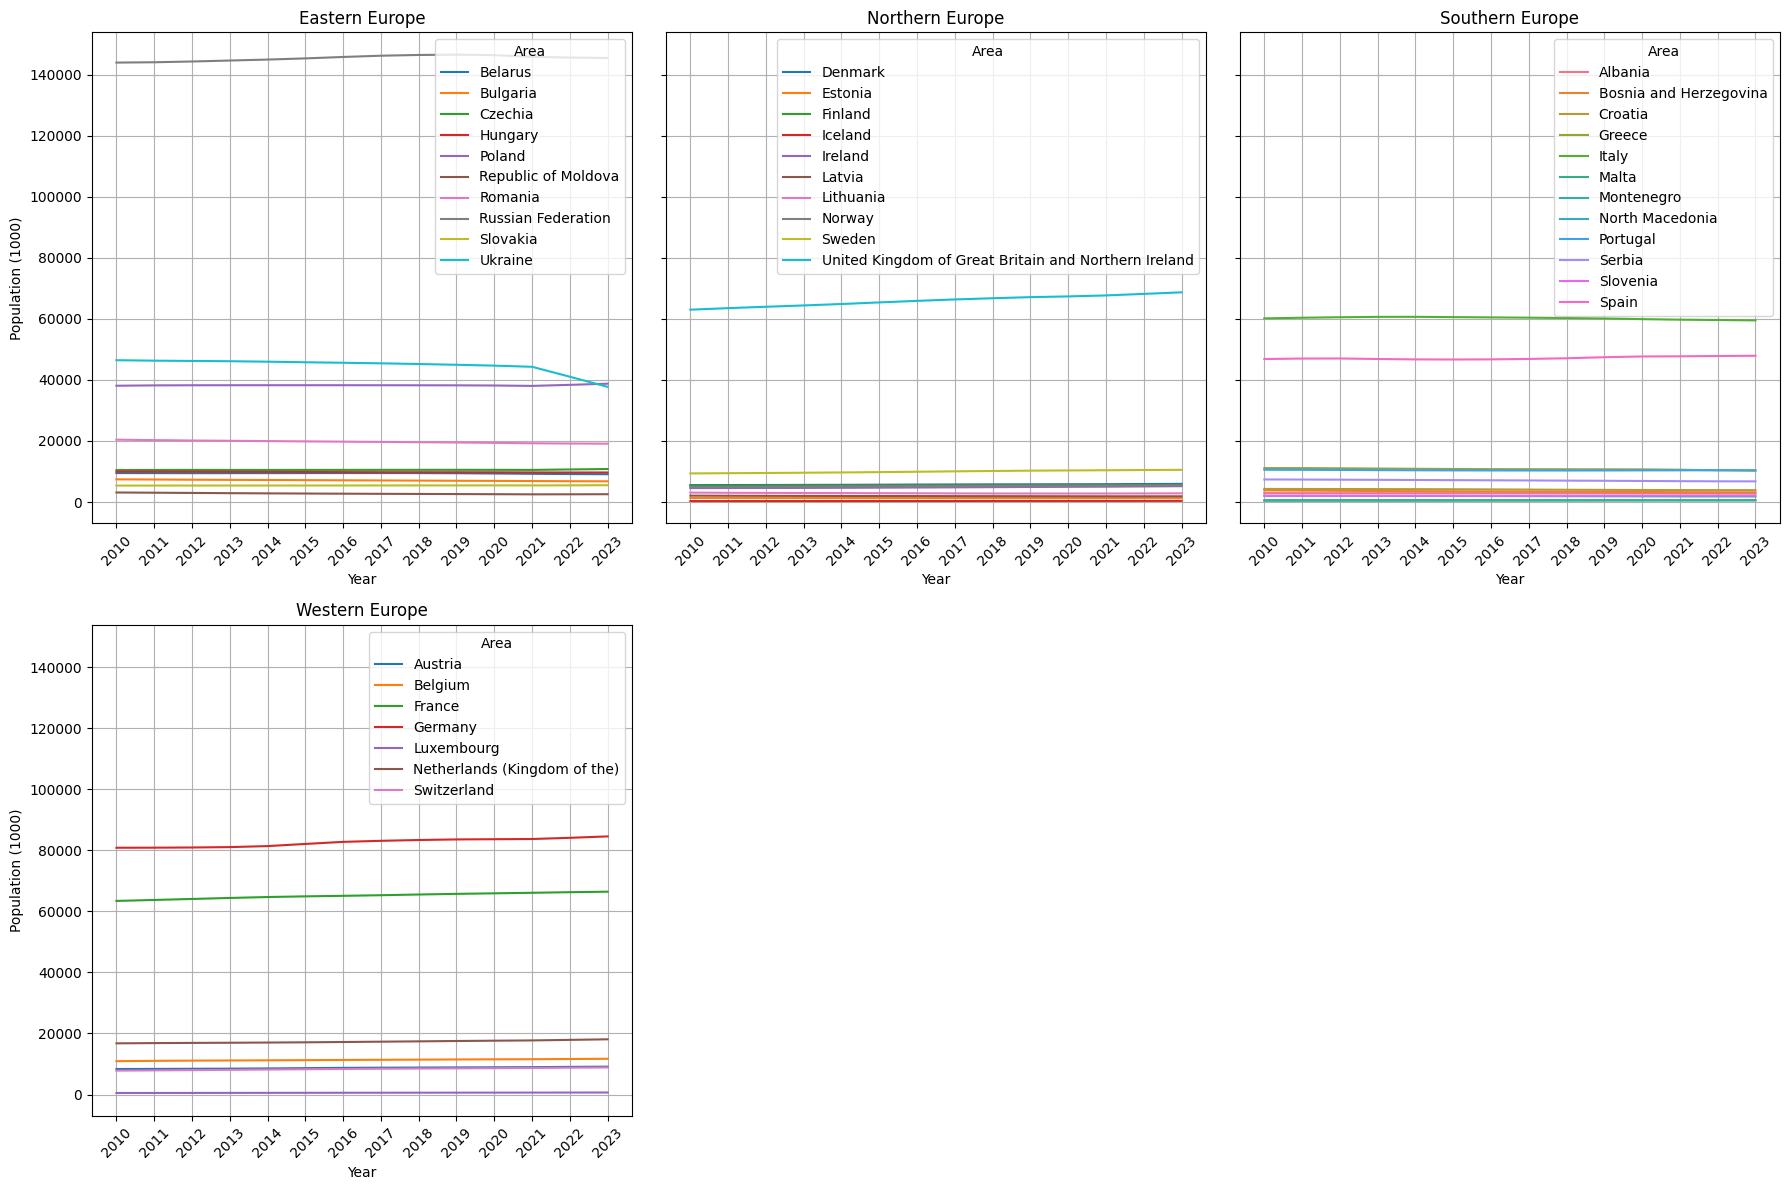

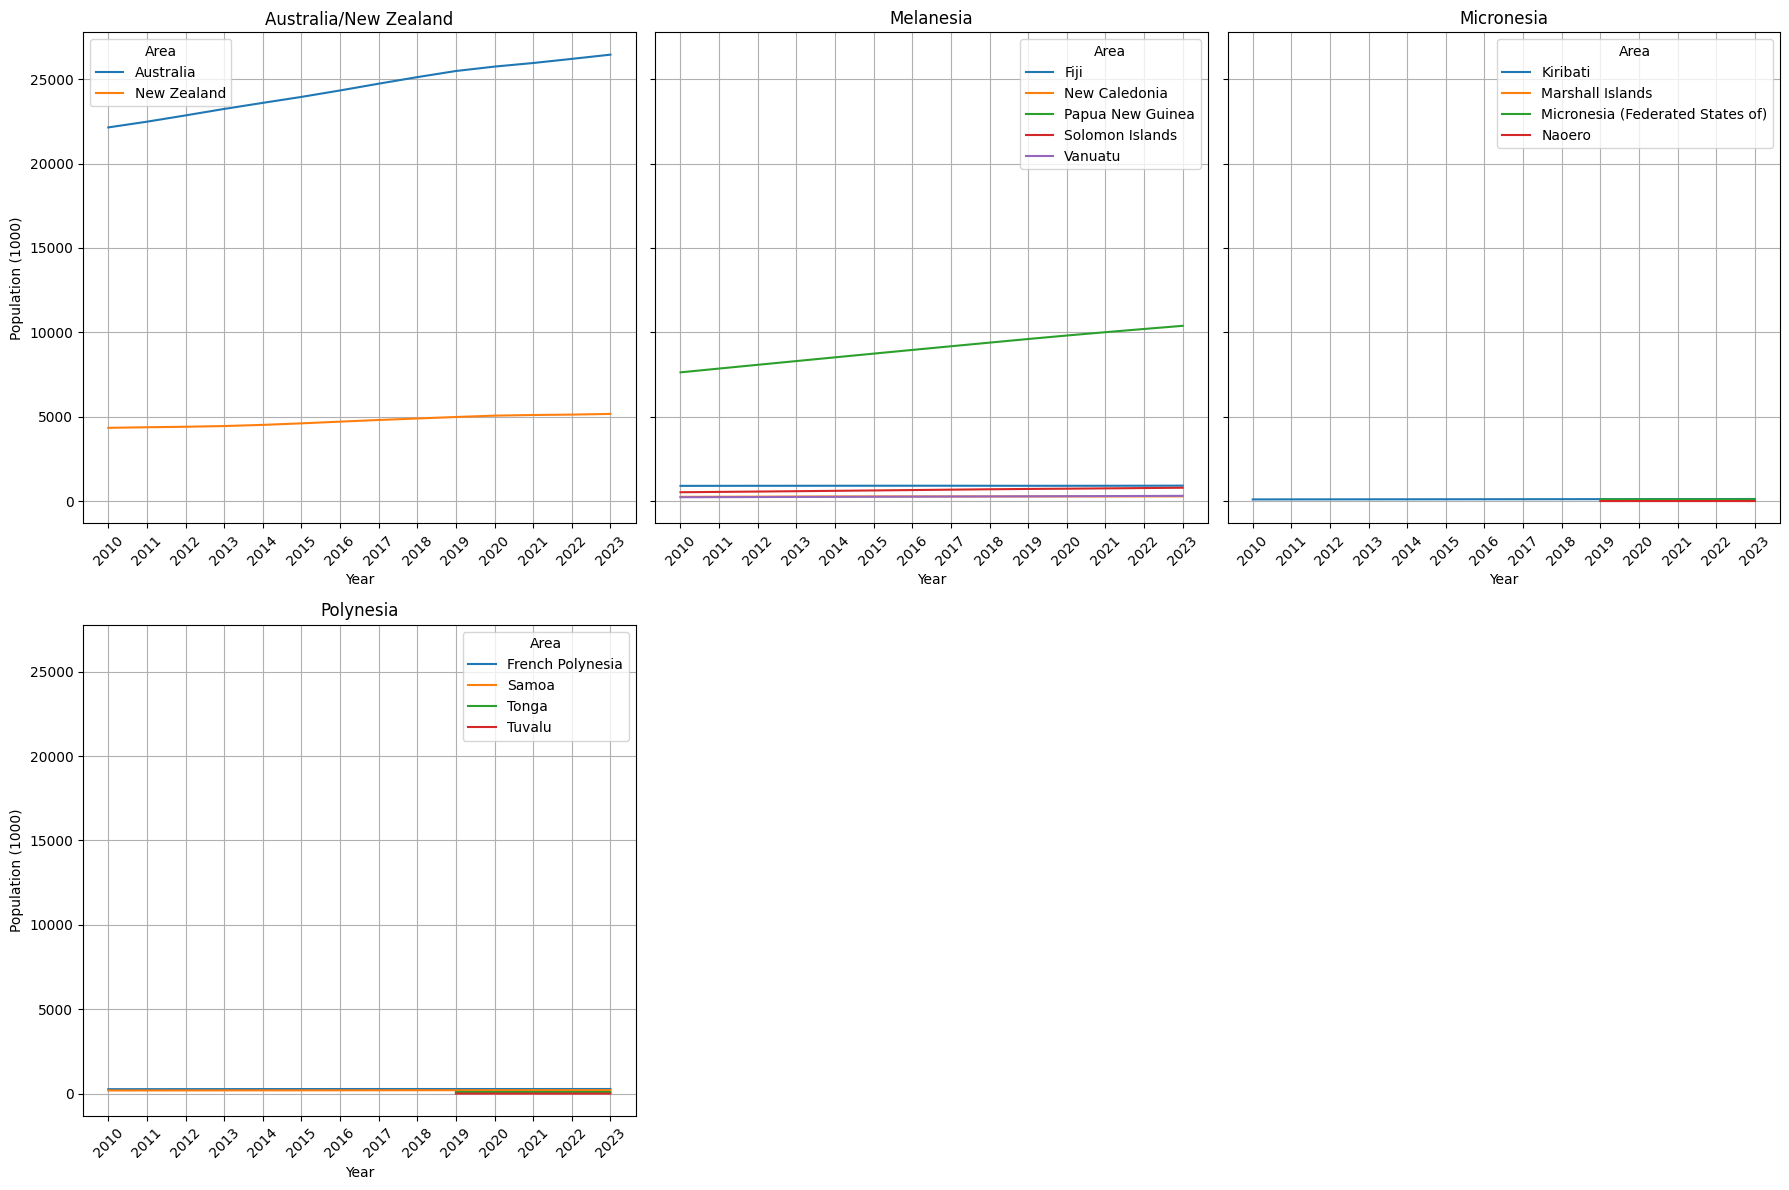

In [35]:
#Population by Region By Country over time
for label, dic in regions.items():

    fig, ax = plt.subplots(2, 3, figsize=(18, 12), sharey=True)
    axes = ax.flatten()

    for i, (sublabel, df) in enumerate(dic.items()):

        df = df[df['Item'] == "Population"][["Area", "Year", "Unit", "Value"]]
        df["Value"]=df["Value"].apply(lambda x: np.nan() if x.strip() == "" else x)
        df["Value"] = df["Value"].astype(float)

        sns.lineplot(
            data=df,
            x="Year",
            y="Value",
            hue="Area",
            ax=axes[i]
        )

        axes[i].set_title(sublabel)
        axes[i].set_xlabel("Year")
        axes[i].set_ylabel("Population (1000)")
        axes[i].grid(True)
        axes[i].tick_params(axis='x', labelrotation=45)

    # Remove unused subplots
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

In [36]:
#identifying where population is decreasing numerically because it's not obvious from the graphs
for dic in regions.values():
  for area, df in dic.items():
    print(area)
    df = df[df['Item'] == "Population"][["Area", "Year", "Unit", "Value"]]
    df["Value"] = df["Value"].astype(float)
    df = df.sort_values(["Area", "Year"]).copy()
    df["previous_population"] = df.groupby("Area")["Value"].shift(1)
    decreases = df[df["Value"] < df["previous_population"]]
    display(decreases)
    print(f"Unique Countries: {decreases.Area.nunique()}")

East Africa


,Area,Year,Unit,Value,previous_population
1668,Mauritius,2016,1000 No,1291.80,1292.28
1669,Mauritius,2017,1000 No,1290.65,1291.80
1670,Mauritius,2018,1000 No,1288.83,1290.65
1671,Mauritius,2019,1000 No,1286.27,1288.83
1672,Mauritius,2020,1000 No,1283.22,1286.27
1673,Mauritius,2021,1000 No,1279.62,1283.22
1674,Mauritius,2022,1000 No,1276.13,1279.62
1675,Mauritius,2023,1000 No,1273.59,1276.13


Unique Countries: 1
West Africa


,Area,Year,Unit,Value,previous_population


Unique Countries: 0
Middle Africa


...

Unique Countries: 2
Micronesia


,Area,Year,Unit,Value,previous_population
276,Marshall Islands,2020,1000 No,42.71,44.01
277,Marshall Islands,2021,1000 No,41.37,42.71
278,Marshall Islands,2022,1000 No,40.08,41.37
279,Marshall Islands,2023,1000 No,38.83,40.08


Unique Countries: 1
Polynesia


,Area,Year,Unit,Value,previous_population
8,French Polynesia,2018,1000 No,279.82,280.09
9,French Polynesia,2019,1000 No,279.03,279.82
569,Tonga,2021,1000 No,105.49,105.70
570,Tonga,2022,1000 No,105.04,105.49
571,Tonga,2023,1000 No,104.60,105.04
663,Tuvalu,2020,1000 No,10.40,10.58
664,Tuvalu,2021,1000 No,10.19,10.40
665,Tuvalu,2022,1000 No,9.99,10.19
666,Tuvalu,2023,1000 No,9.82,9.99


Unique Countries: 3


In [37]:
#what countries had the greatest overall decrease?
world_decreases = pd.DataFrame()
for dic in regions.values():
  for area, df in dic.items():
    print(area)
    df = df[df['Item'] == "Population"][["Area", "Year", "Unit", "Value"]]
    df["Value"] = df["Value"].astype(float)
    df = df.sort_values(["Area", "Year"]).copy()

    df["highest_population_so_far"] = (
        df.groupby("Area")["Value"].cummax()
    )
    #print(df.head())
    df["decrease_from_peak"] = (
        df["highest_population_so_far"] - df["Value"]
    )

    largest_decreases = (
        df.loc[df.groupby("Area")["decrease_from_peak"].idxmax()]
          .sort_values("decrease_from_peak", ascending=False)
    )
    world_decreases = pd.concat([world_decreases, largest_decreases])
    display(
        largest_decreases[largest_decreases['decrease_from_peak'] != 0][
            ["Area", "Year", "Value",
            "highest_population_so_far", "decrease_from_peak"]
        ].head(10)
    )
print('Overall')
display(world_decreases[world_decreases['decrease_from_peak'] != 0][
            ["Area", "Year", "Value",
            "highest_population_so_far", "decrease_from_peak"]].sort_values("decrease_from_peak", ascending=False).head(10))

East Africa


,Area,Year,Value,highest_population_so_far,decrease_from_peak
1675,Mauritius,2023,1273.59,1292.28,18.69


West Africa


,Area,Year,Value,highest_population_so_far,decrease_from_peak


Middle Africa


...

,Area,Year,Value,highest_population_so_far,decrease_from_peak
279,Marshall Islands,2023,38.83,44.01,5.18


Polynesia


,Area,Year,Value,highest_population_so_far,decrease_from_peak
571,Tonga,2023,104.60,105.70,1.10
9,French Polynesia,2019,279.03,280.09,1.06
666,Tuvalu,2023,9.82,10.58,0.76


Overall


,Area,Year,Value,highest_population_so_far,decrease_from_peak
2523,Ukraine,2023,37732.84,46456.00,8723.16
587,"China, mainland",2023,1422584.93,1426437.27,3852.34
3264,Syrian Arab Republic,2016,19193.83,22878.10,3684.27
2954,Venezuela (Bolivarian Republic of),2022,28213.02,30765.72,2552.70
1687,Romania,2023,19118.48,20432.57,1314.09
1007,Italy,2023,59499.45,60664.17,1164.72
1967,Russian Federation,2023,145440.50,146533.07,1092.57
727,Greece,2023,10242.91,11124.67,881.76
2337,Lebanon,2020,5702.40,6472.47,770.07
293,Bulgaria,2023,6795.80,7437.60,641.80


In [38]:
#now let's find where population is most increasing
world_increases = pd.DataFrame()
for dic in regions.values():
  for area, df in dic.items():
    print(area)
    df = df[df['Item'] == "Population"][["Area", "Year", "Unit", "Value"]]
    df["Value"] = df["Value"].astype(float)
    df = df.sort_values(["Area", "Year"]).copy()

    df["lowest_population_so_far"] = (
        df.groupby("Area")["Value"].cummin()
    )
    #print(df.head())
    df["increase_from_low"] = (
        df["Value"] - df["lowest_population_so_far"]
    )

    largest_increases = (
        df.loc[df.groupby("Area")["increase_from_low"].idxmax()]
          .sort_values("increase_from_low", ascending=False)
    )
    world_increases = pd.concat([world_increases, largest_increases])
    display(
        largest_increases[largest_increases['increase_from_low'] != 0][
            ["Area", "Year", "Value",
            "lowest_population_so_far", "increase_from_low"]
        ].head(10)
    )
print('Overall')
display(world_increases[world_increases['increase_from_low'] != 0][
            ["Area", "Year", "Value",
            "lowest_population_so_far", "increase_from_low"]].sort_values("increase_from_low", ascending=False).head(10))

East Africa


,Area,Year,Value,lowest_population_so_far,increase_from_low
559,Ethiopia,2023,128691.69,90538.51,38153.18
3081,United Republic of Tanzania,2023,66617.61,44758.49,21859.12
2801,Uganda,2023,48656.60,32390.80,16265.80
834,Kenya,2023,55339.00,41598.57,13740.43
1966,Mozambique,2023,33635.16,22999.24,10635.92
1128,Madagascar,2023,31195.93,22183.34,9012.59
3356,Zambia,2023,20723.97,13965.59,6758.38
1402,Malawi,2023,21104.48,14826.46,6278.02
2241,Rwanda,2023,13954.47,10317.55,3636.92
3636,Zimbabwe,2023,16340.82,13356.55,2984.27


West Africa


,Area,Year,Value,lowest_population_so_far,increase_from_low
2760,Nigeria,2023,227882.95,166642.89,61240.06
2484,Niger,2023,26159.87,16548.83,9611.04
576,Côte d'Ivoire,2023,31165.65,22488.06,8677.59
1129,Ghana,2023,33787.91,25474.99,8312.92
13,Burkina Faso,2023,23025.78,16176.50,6849.28
3040,Senegal,2023,18077.57,12635.41,5442.16
1409,Guinea,2023,14405.47,10396.09,4009.38
3320,Sierra Leone,2023,8460.51,6222.71,2237.80
2218,Mauritania,2023,5022.44,3390.96,1631.48
1947,Liberia,2023,5493.03,4058.89,1434.14


Middle Africa


...

,Area,Year,Value,lowest_population_so_far,increase_from_low
13,Kiribati,2023,132.53,108.70,23.83
374,Micronesia (Federated States of),2023,112.63,110.28,2.35
442,Naoero,2023,11.88,11.59,0.29


Polynesia


,Area,Year,Value,lowest_population_so_far,increase_from_low
301,Samoa,2023,216.66,193.02,23.64
13,French Polynesia,2023,281.12,270.58,10.54
568,Tonga,2020,105.70,105.67,0.03


Overall


,Area,Year,Value,lowest_population_so_far,increase_from_low
662,India,2023,1438069.60,1243481.56,194588.04
585,"China, mainland",2021,1426437.27,1351561.51,74875.76
2760,Nigeria,2023,227882.95,166642.89,61240.06
1789,Pakistan,2023,247504.50,199239.05,48265.45
559,Ethiopia,2023,128691.69,90538.51,38153.18
844,Democratic Republic of the Congo,2023,105789.73,68563.04,37226.69
302,Indonesia,2023,281190.07,246305.32,34884.75
293,United States of America,2023,343477.34,311062.79,32414.55
290,Egypt,2023,114535.77,89196.07,25339.70
3081,United Republic of Tanzania,2023,66617.61,44758.49,21859.12


### Infant Food

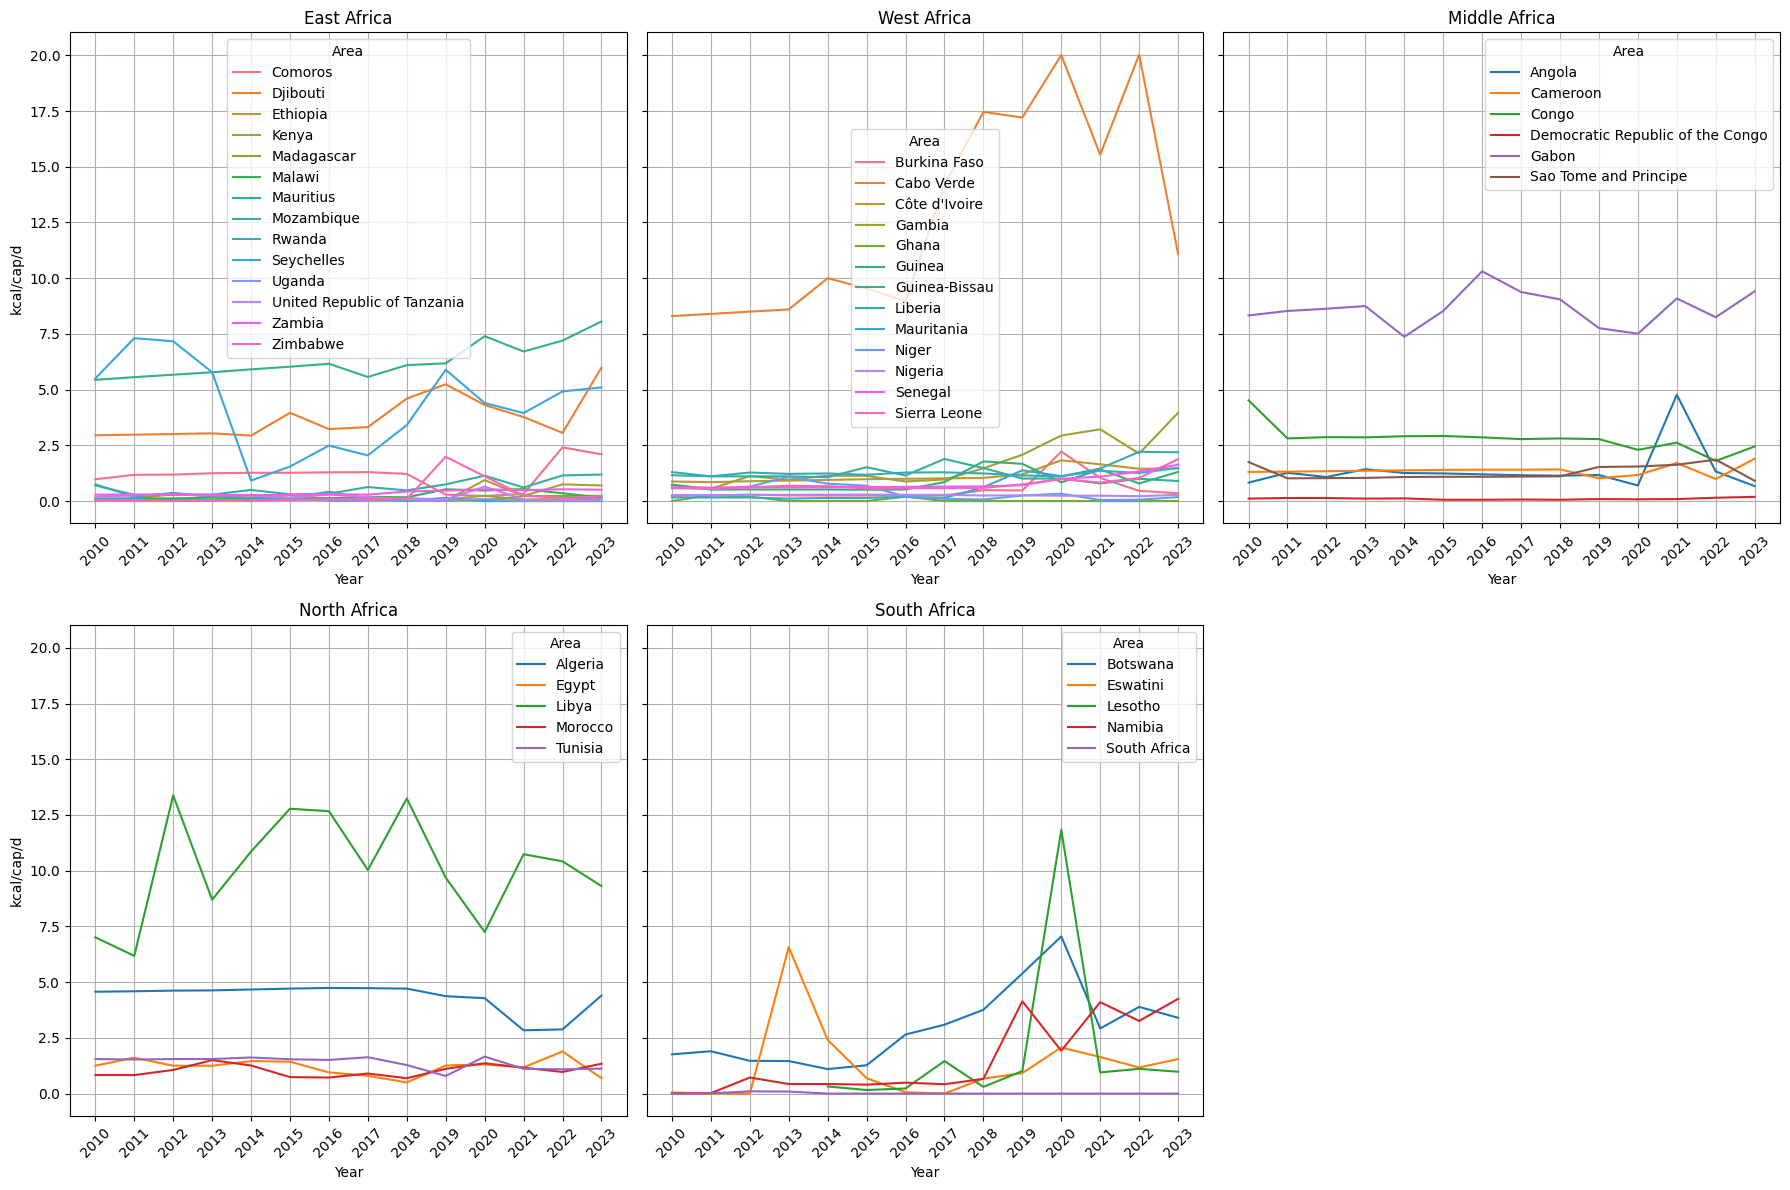

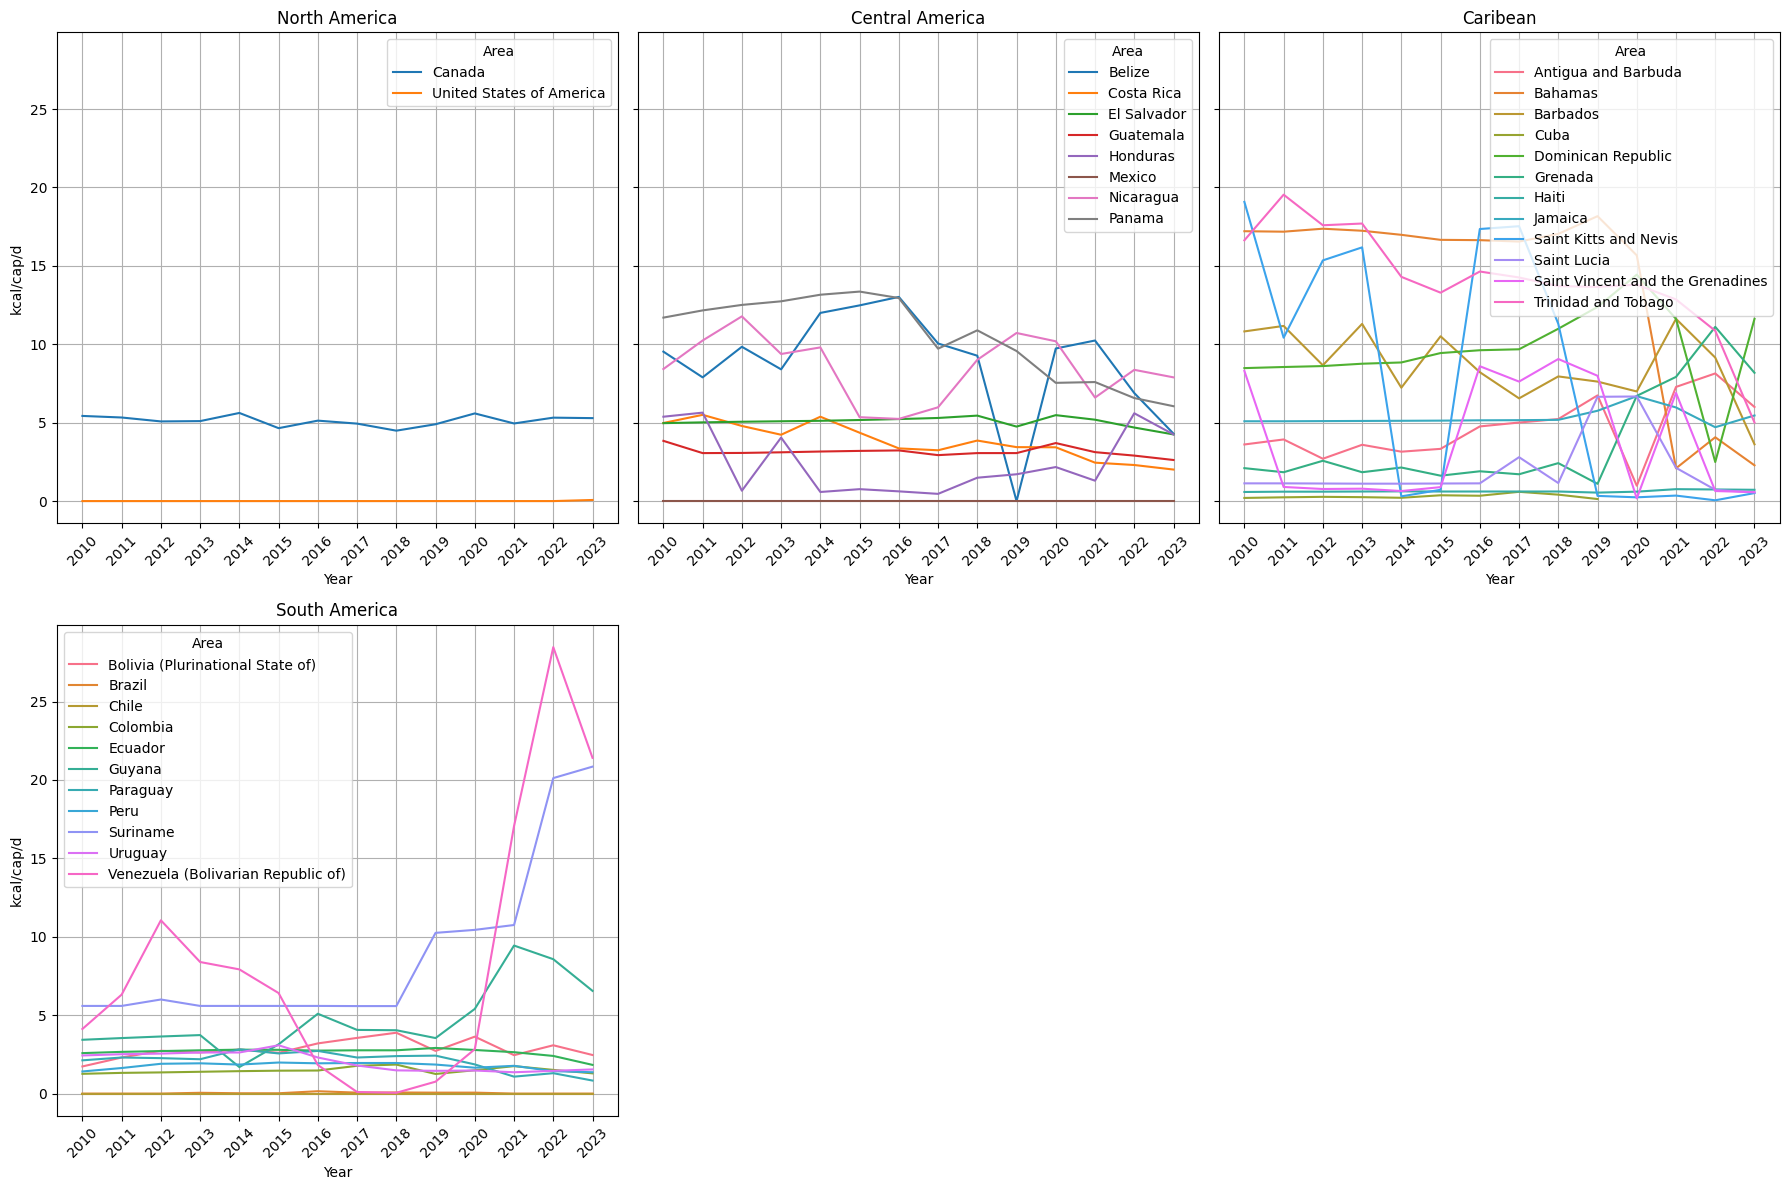

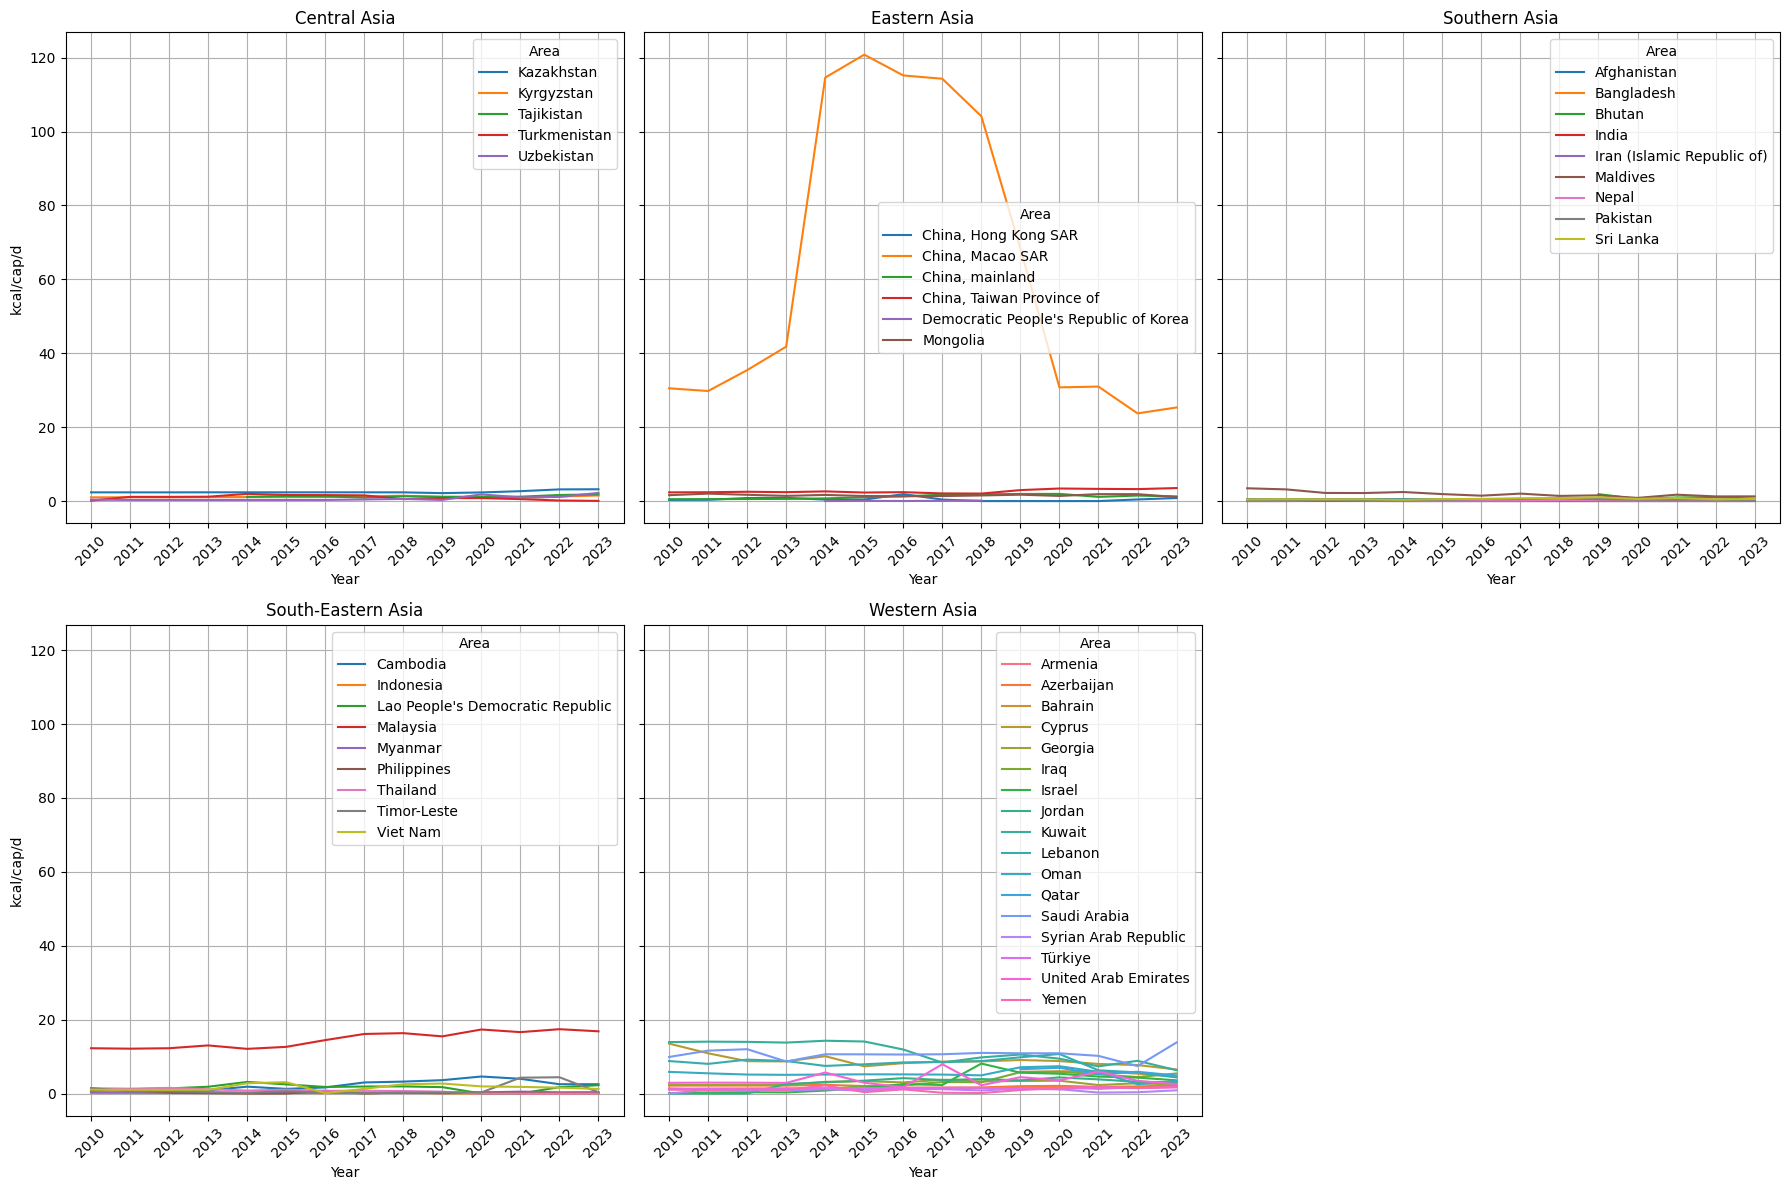

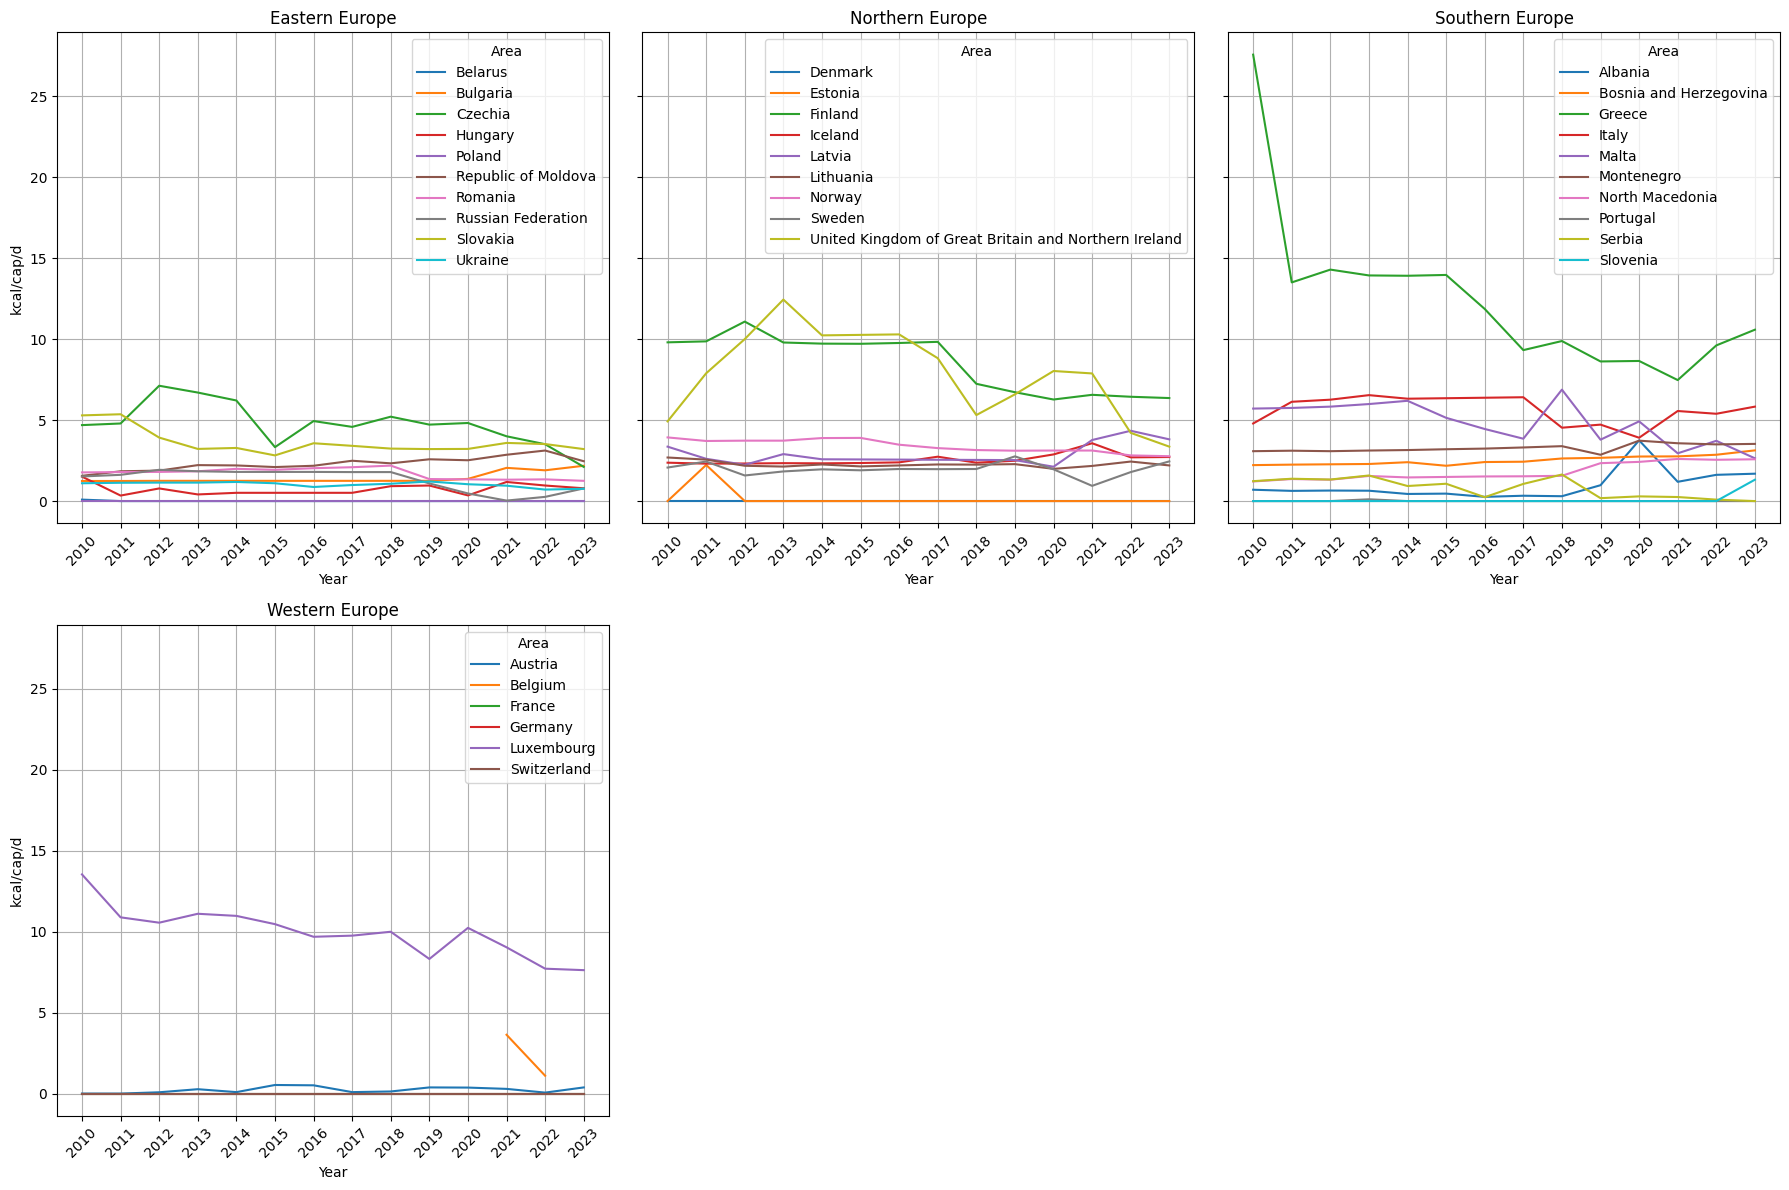

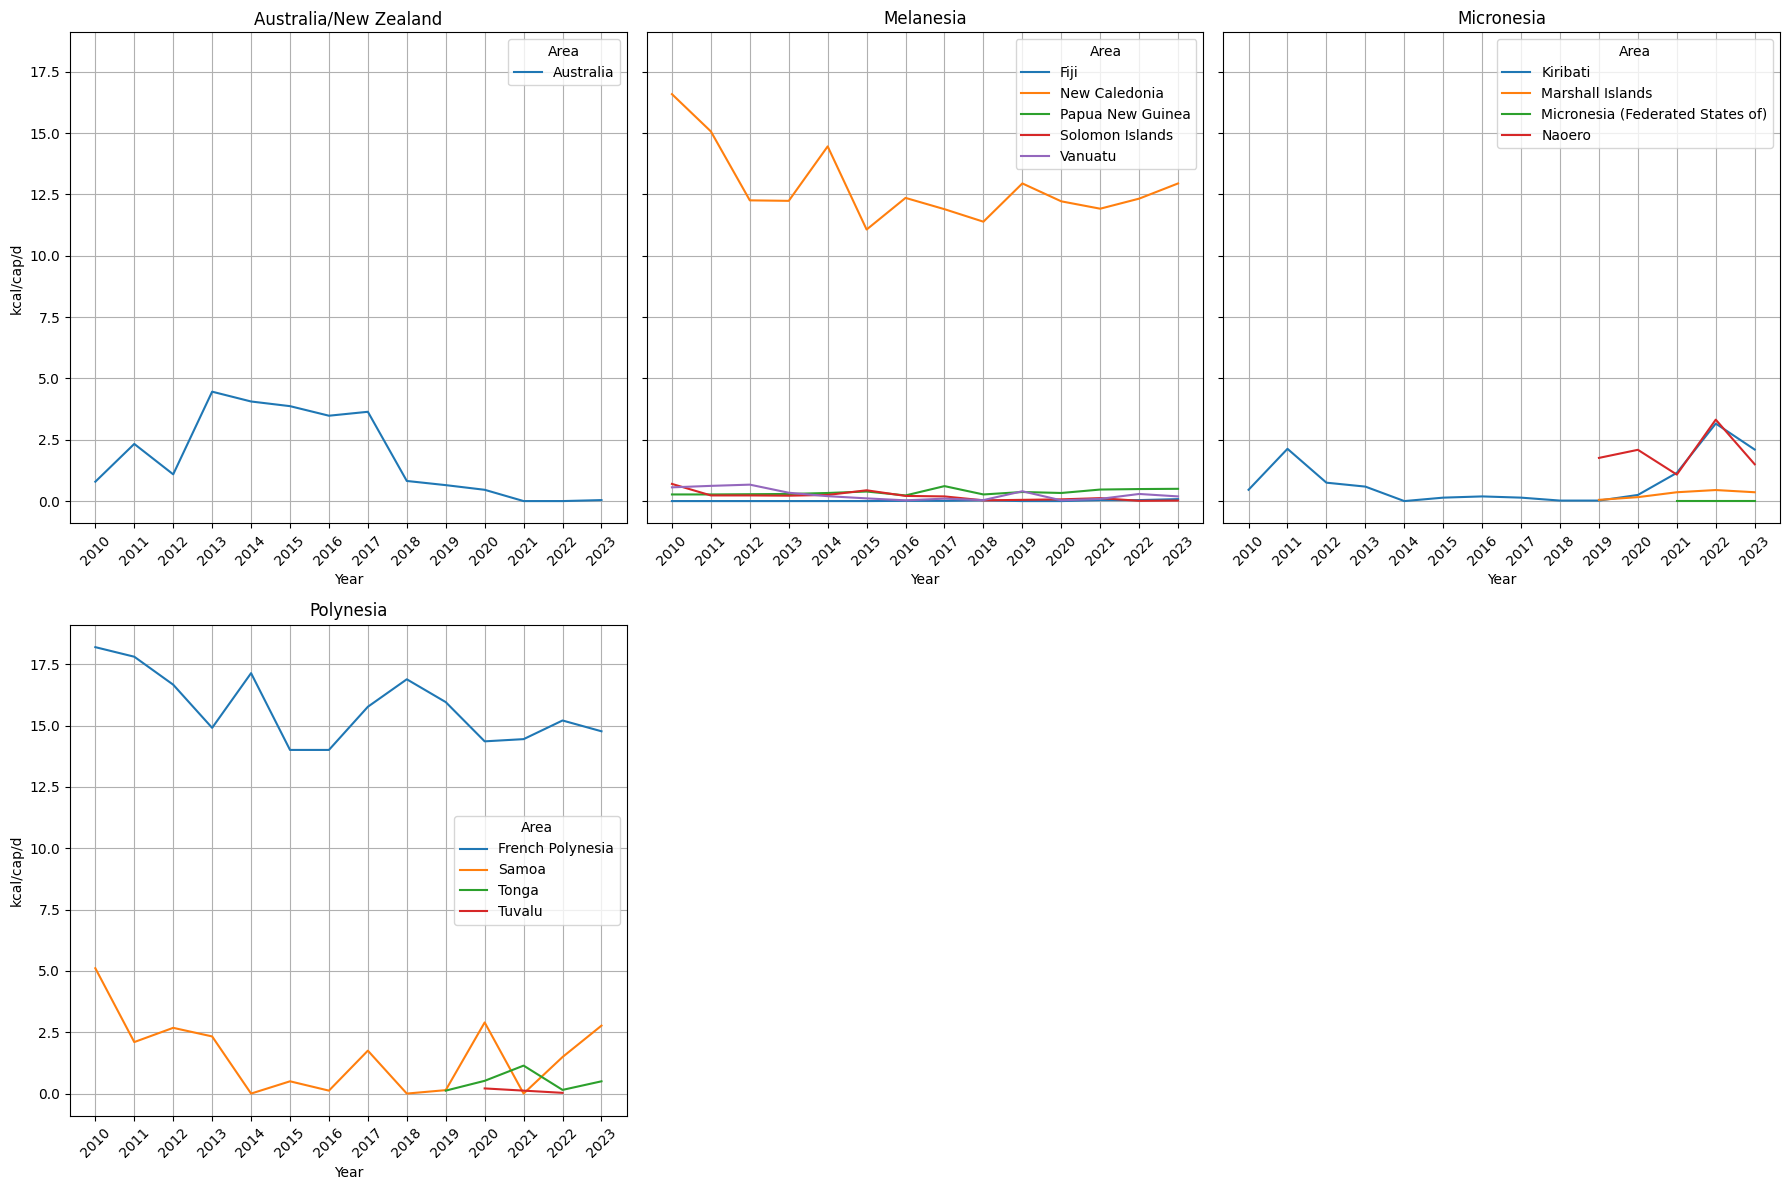

In [39]:
#Per Capita Calorie Supply of infant food by Region and Country over time

for label, dic in regions.items():

    fig, ax = plt.subplots(2, 3, figsize=(18, 12), sharey=True)
    axes = ax.flatten()

    for i, (sublabel, df) in enumerate(dic.items()):

        df = df[(df['Item'] == "Infant food")&(df['Unit']=="kcal/cap/d")][["Area", "Year", "Unit", "Value"]]
        df["Value"]=df["Value"].apply(lambda x: np.nan() if x.strip() == "" else x)
        df["Value"] = df["Value"].astype(float)

        sns.lineplot(
            data=df,
            x="Year",
            y="Value",
            hue="Area",
            ax=axes[i]
        )

        axes[i].set_title(sublabel)
        axes[i].set_xlabel("Year")
        axes[i].set_ylabel("kcal/cap/d")
        axes[i].grid(True)
        axes[i].tick_params(axis='x', labelrotation=45)

    # Remove unused subplots
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

In [40]:
central_america[(central_america['Item'] == "Infant food")&(central_america['Unit']=="kcal/cap/d")&(central_america['Area'] == "Mexico")]

,Domain Code,Domain,Area Code (M49),Area,Element Code,Element,Item Code,Item,Year Code,Year,Unit,Value
1546,FBS,Food Balances (2010-),484,Mexico,664,Food supply (kcal/capita/day),2680,Infant food,2010,2010,kcal/cap/d,0
1559,FBS,Food Balances (2010-),484,Mexico,664,Food supply (kcal/capita/day),2680,Infant food,2011,2011,kcal/cap/d,0
1572,FBS,Food Balances (2010-),484,Mexico,664,Food supply (kcal/capita/day),2680,Infant food,2012,2012,kcal/cap/d,0
1585,FBS,Food Balances (2010-),484,Mexico,664,Food supply (kcal/capita/day),2680,Infant food,2013,2013,kcal/cap/d,0
1598,FBS,Food Balances (2010-),484,Mexico,664,Food supply (kcal/capita/day),2680,Infant food,2014,2014,kcal/cap/d,0
1611,FBS,Food Balances (2010-),484,Mexico,664,Food supply (kcal/capita/day),2680,Infant food,2015,2015,kcal/cap/d,0
1624,FBS,Food Balances (2010-),484,Mexico,664,Food supply (kcal/capita/day),2680,Infant food,2016,2016,kcal/cap/d,0
1637,FBS,Food Balances (2010-),484,Mexico,664,Food supply (kcal/capita/day),2680,Infant food,2017,2017,kcal/cap/d,0
1650,FBS,Food Balances (2010-),484,Mexico,664,Food supply (kcal/capita/day),2680,Infant food,2018,2018,kcal/cap/d,0
1663,FBS,Food Balances (2010-),484,Mexico,664,Food supply (kcal/capita/day),2680,Infant food,2019,2019,kcal/cap/d,0


In [41]:
western_europe[(western_europe['Item'] == "Infant food")&(western_europe['Unit']=="kcal/cap/d")&(western_europe['Area'] == "Switzerland")]

,Domain Code,Domain,Area Code (M49),Area,Element Code,Element,Item Code,Item,Year Code,Year,Unit,Value
1578,FBS,Food Balances (2010-),756,Switzerland,664,Food supply (kcal/capita/day),2680,Infant food,2010,2010,kcal/cap/d,0
1590,FBS,Food Balances (2010-),756,Switzerland,664,Food supply (kcal/capita/day),2680,Infant food,2011,2011,kcal/cap/d,0
1602,FBS,Food Balances (2010-),756,Switzerland,664,Food supply (kcal/capita/day),2680,Infant food,2012,2012,kcal/cap/d,0
1614,FBS,Food Balances (2010-),756,Switzerland,664,Food supply (kcal/capita/day),2680,Infant food,2013,2013,kcal/cap/d,0
1627,FBS,Food Balances (2010-),756,Switzerland,664,Food supply (kcal/capita/day),2680,Infant food,2014,2014,kcal/cap/d,0
1640,FBS,Food Balances (2010-),756,Switzerland,664,Food supply (kcal/capita/day),2680,Infant food,2015,2015,kcal/cap/d,0
1653,FBS,Food Balances (2010-),756,Switzerland,664,Food supply (kcal/capita/day),2680,Infant food,2016,2016,kcal/cap/d,0
1666,FBS,Food Balances (2010-),756,Switzerland,664,Food supply (kcal/capita/day),2680,Infant food,2017,2017,kcal/cap/d,0
1679,FBS,Food Balances (2010-),756,Switzerland,664,Food supply (kcal/capita/day),2680,Infant food,2018,2018,kcal/cap/d,0
1692,FBS,Food Balances (2010-),756,Switzerland,664,Food supply (kcal/capita/day),2680,Infant food,2019,2019,kcal/cap/d,0


In [42]:
north_america[(north_america['Item'] == "Infant food")&(north_america['Unit']=="kcal/cap/d")&(north_america['Area'] == "United States of America")]

,Domain Code,Domain,Area Code (M49),Area,Element Code,Element,Item Code,Item,Year Code,Year,Unit,Value
384,FBS,Food Balances (2010-),840,United States of America,664,Food supply (kcal/capita/day),2680,Infant food,2010,2010,kcal/cap/d,0
396,FBS,Food Balances (2010-),840,United States of America,664,Food supply (kcal/capita/day),2680,Infant food,2011,2011,kcal/cap/d,0
408,FBS,Food Balances (2010-),840,United States of America,664,Food supply (kcal/capita/day),2680,Infant food,2012,2012,kcal/cap/d,0
420,FBS,Food Balances (2010-),840,United States of America,664,Food supply (kcal/capita/day),2680,Infant food,2013,2013,kcal/cap/d,0
433,FBS,Food Balances (2010-),840,United States of America,664,Food supply (kcal/capita/day),2680,Infant food,2014,2014,kcal/cap/d,0
446,FBS,Food Balances (2010-),840,United States of America,664,Food supply (kcal/capita/day),2680,Infant food,2015,2015,kcal/cap/d,0
459,FBS,Food Balances (2010-),840,United States of America,664,Food supply (kcal/capita/day),2680,Infant food,2016,2016,kcal/cap/d,0
472,FBS,Food Balances (2010-),840,United States of America,664,Food supply (kcal/capita/day),2680,Infant food,2017,2017,kcal/cap/d,0
485,FBS,Food Balances (2010-),840,United States of America,664,Food supply (kcal/capita/day),2680,Infant food,2018,2018,kcal/cap/d,0
498,FBS,Food Balances (2010-),840,United States of America,664,Food supply (kcal/capita/day),2680,Infant food,2019,2019,kcal/cap/d,0


## Finding General Calorie Supply Extremes

In [43]:
#most available food per capita in any year

highest_food_supply = pd.DataFrame()
for dic in regions.values():
  for area, df in dic.items():
    print(area)
    df = df[(df['Item'] == "Grand Total")&(df['Unit']=="kcal/cap/d")][["Area", "Year", "Unit", "Value"]]
    df["Value"] = df["Value"].astype(float)
    df = df.sort_values(["Area", "Year"]).copy()
    df["highest_food_supply"] = (
        df.groupby("Area")["Value"].cummax()
    )
    largest_food_supply = (
        df.loc[df.groupby("Area")["highest_food_supply"].idxmax()]
          .sort_values("highest_food_supply", ascending=False)
    )
    highest_food_supply = pd.concat([highest_food_supply, largest_food_supply])
    display(
        largest_food_supply[
            ["Area", "Year", "Value",
            "highest_food_supply"]
        ].head(10)
    )
print("Overall")
display(highest_food_supply[highest_food_supply['highest_food_supply'] != 0][
            ["Area", "Year", "Value",
            "highest_food_supply"]].sort_values("highest_food_supply", ascending=False).head(10))

East Africa


,Area,Year,Value,highest_food_supply
1754,Mauritius,2023,3255.54,3255.54
2570,Seychelles,2018,2909.23,2909.23
350,Djibouti,2020,2764.18,2764.18
1469,Malawi,2021,2642.28,2642.28
632,Ethiopia,2022,2563.25,2563.25
3160,United Republic of Tanzania,2023,2518.33,2518.33
50,Comoros,2016,2506.62,2506.62
2874,Uganda,2022,2495.40,2495.40
2314,Rwanda,2022,2477.34,2477.34
3715,Zimbabwe,2023,2393.38,2393.38


West Africa


,Area,Year,Value,highest_food_supply
1196,Ghana,2021,3143.69,3143.69
2291,Mauritania,2022,2954.96,2954.96
1488,Guinea,2023,2947.55,2947.55
649,Côte d'Ivoire,2022,2946.38,2946.38
3119,Senegal,2023,2847.77,2847.77
354,Cabo Verde,2020,2844.07,2844.07
92,Burkina Faso,2023,2790.88,2790.88
2545,Niger,2020,2712.99,2712.99
1741,Guinea-Bissau,2020,2694.48,2694.48
857,Gambia,2010,2676.13,2676.13


Middle Africa


...

,Area,Year,Value,highest_food_supply
304,Marshall Islands,2023,3322.43,3322.43
68,Kiribati,2019,3131.79,3131.79
467,Naoero,2023,3087.34,3087.34
387,Micronesia (Federated States of),2021,2804.84,2804.84


Polynesia


,Area,Year,Value,highest_food_supply
691,Tuvalu,2023,3300.92,3300.92
374,Samoa,2022,3178.29,3178.29
80,French Polynesia,2021,3139.39,3139.39
596,Tonga,2023,3059.05,3059.05


Overall


,Area,Year,Value,highest_food_supply
1193,Ireland,2019,3966.57,3966.57
372,United States of America,2023,3947.33,3947.33
372,Belgium,2023,3921.31,3921.31
1574,Israel,2022,3916.81,3916.81
3624,Türkiye,2023,3892.23,3892.23
2488,Serbia,2023,3878.93,3878.93
20,Austria,2011,3834.49,3834.49
62,Denmark,2018,3816.42,3816.42
3050,Saudi Arabia,2019,3786.13,3786.13
1086,Italy,2023,3752.66,3752.66


In [44]:
#highest increase in supply

In [45]:
#least available food per capita



In [46]:
#largest decrease in supply